# Notebook 01: Data Exploration 
 
**Purpose:** Understand raw dataset characteristics and quality 
 
**Key Tasks:** 
1. Load and analyze raw audio files 
2. Calculate dataset statistics 
3. Perform quality checks 
4. Create visualizations 
5. Log to MLflow 
 
---

## 1. Import Libraries

In [3]:
import os 
import sys 
from pathlib import Path 
import json 
from datetime import datetime 
 
# Audio processing 
import librosa 
import librosa.display 
 
# Data manipulation 
import numpy as np 
import pandas as pd 
 
# Visualization 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
# MLflow 
import mlflow 
 
# Progress tracking 
from tqdm import tqdm 
 
plt.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette('husl') 
 
print('✓ Libraries imported')

✓ Libraries imported


## 2. Project Setup

In [23]:
PROJECT_ROOT = Path('/Users/harryirving/Development/projects/ai-ml/BikeAIv5') 
os.chdir(PROJECT_ROOT) 
 
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw' 
RESULTS_DIR = PROJECT_ROOT / 'results' 
FIGURES_DIR = RESULTS_DIR / 'figures' 
LOGS_DIR = PROJECT_ROOT / 'logs' 
DATA_DIR = PROJECT_ROOT / 'data' 
 
FIGURES_DIR.mkdir(parents=True, exist_ok=True) 
 
CLASS_DIRS = { 
    'grinder': RAW_DATA_DIR / 'grinder', 
    'background': RAW_DATA_DIR / 'background', 
    'tools': RAW_DATA_DIR / 'tools' 
} 
 
print(f'Project Root: {PROJECT_ROOT}')

Project Root: /Users/harryirving/Development/projects/ai-ml/BikeAIv5


## 3. Setup MLflow

In [5]:
mlflow.set_tracking_uri(f'file://{LOGS_DIR / "mlruns"}') 
mlflow.set_experiment('angle_grinder_pipeline') 
print('✓ MLflow configured')

✓ MLflow configured


## 4. Scan Raw Audio Files

In [6]:
def find_audio_files(directory): 
    audio_extensions = {'.wav', '.mp3', '.flac', '.ogg', '.m4a'} 
    if not directory.exists(): 
        return [] 
    audio_files = [] 
    for ext in audio_extensions: 
        audio_files.extend(directory.glob(f'*{ext}')) 
    return sorted(audio_files) 
 
audio_files_by_class = {cls: find_audio_files(dir) for cls, dir in CLASS_DIRS.items()} 
 
print('='*50) 
total_files = 0 
for class_name, files in audio_files_by_class.items(): 
    count = len(files) 
    total_files += count 
    print(f'{class_name}: {count} files') 
print('='*50) 
print(f'Total: {total_files} files') 
if total_files == 0: 
    print('⚠️  No audio files found!')

grinder: 36 files
background: 1348 files
tools: 21 files
Total: 1405 files


## 5. Load and Analyze Audio

In [7]:
def analyze_audio_file(filepath): 
    try: 
        audio, sr = librosa.load(filepath, sr=None) 
        duration = librosa.get_duration(y=audio, sr=sr) 
        max_amplitude = np.max(np.abs(audio)) 
        is_clipped = max_amplitude >= 0.99 
        non_silent = librosa.effects.split(audio, top_db=20) 
        silence_ratio = 1.0 - (sum(end-start for start,end in non_silent) / len(audio)) 
        rms = np.sqrt(np.mean(audio**2)) 
        zcr = np.mean(librosa.feature.zero_crossing_rate(audio)) 
        return { 
            'filepath': str(filepath), 
            'filename': filepath.name, 
            'sample_rate': sr, 
            'duration': duration, 
            'max_amplitude': max_amplitude, 
            'is_clipped': is_clipped, 
            'silence_ratio': silence_ratio, 
            'rms_energy': rms, 
            'zero_crossing_rate': zcr, 
            'status': 'success' 
        } 
    except Exception as e: 
        return {'filepath': str(filepath), 'filename': filepath.name, 'status': 'failed', 'error': str(e)} 
 
analysis_results = [] 
for class_name, files in audio_files_by_class.items(): 
    if len(files) == 0: continue 
    print(f'Analyzing {class_name}...') 
    for filepath in tqdm(files, desc=f'  {class_name}'): 
        result = analyze_audio_file(filepath) 
        result['class'] = class_name 
        analysis_results.append(result) 
 
df = pd.DataFrame(analysis_results) 
df_success = df[df['status'] == 'success'].copy() 
df_failed = df[df['status'] == 'failed'].copy() 
print(f' ✓ Analyzed {len(df_success)} files successfully') 
if len(df_failed) > 0: 
    print(f'⚠️  Failed: {len(df_failed)} files')

Analyzing grinder...


  grinder: 100%|██████████| 36/36 [00:03<00:00, 10.20it/s]


Analyzing background...


  background: 100%|██████████| 1348/1348 [00:02<00:00, 487.47it/s]


Analyzing tools...


  tools: 100%|██████████| 21/21 [00:01<00:00, 15.61it/s]

 ✓ Analyzed 1405 files successfully


## 6. Dataset Statistics

In [8]:
if len(df_success) > 0: 
    print('='*70) 
    print('DATASET STATISTICS') 
    print('='*70) 
    print(' 1. CLASS DISTRIBUTION') 
    print(df_success['class'].value_counts()) 
    print(' 2. DURATION ANALYSIS') 
    print(df_success['duration'].describe()) 
    for cls in df_success['class'].unique(): 
        class_df = df_success[df_success['class'] == cls] 
        print(f'{cls}: Total={class_df["duration"].sum():.2f}s, Mean={class_df["duration"].mean():.2f}s') 
    print(' 3. SAMPLE RATE DISTRIBUTION') 
    print(df_success['sample_rate'].value_counts()) 
    print(' 4. QUALITY CHECKS') 
    print(f'Clipped files: {df_success["is_clipped"].sum()}') 
    print(f'Mean silence ratio: {df_success["silence_ratio"].mean()*100:.1f}%') 
    print(f'Mean RMS: {df_success["rms_energy"].mean():.4f}') 
    print(f'Mean ZCR: {df_success["zero_crossing_rate"].mean():.4f}')

DATASET STATISTICS
 1. CLASS DISTRIBUTION
class
background    1348
grinder         36
tools           21
Name: count, dtype: int64
 2. DURATION ANALYSIS
count    1405.000000
mean        5.195512
std        19.639681
min         3.000000
25%         3.000000
50%         3.000000
75%         3.000000
max       600.048000
Name: duration, dtype: float64
grinder: Total=1513.04s, Mean=42.03s
background: Total=4708.97s, Mean=3.49s
tools: Total=1077.68s, Mean=51.32s
 3. SAMPLE RATE DISTRIBUTION
sample_rate
16000    1346
44100      25
48000      18
24000      16
Name: count, dtype: int64
 4. QUALITY CHECKS
Clipped files: 25
Mean silence ratio: 5.1%
Mean RMS: 0.0485
Mean ZCR: 0.0690


## 7. Data Visualizations

✓ Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/figures/01_dataset_statistics.png


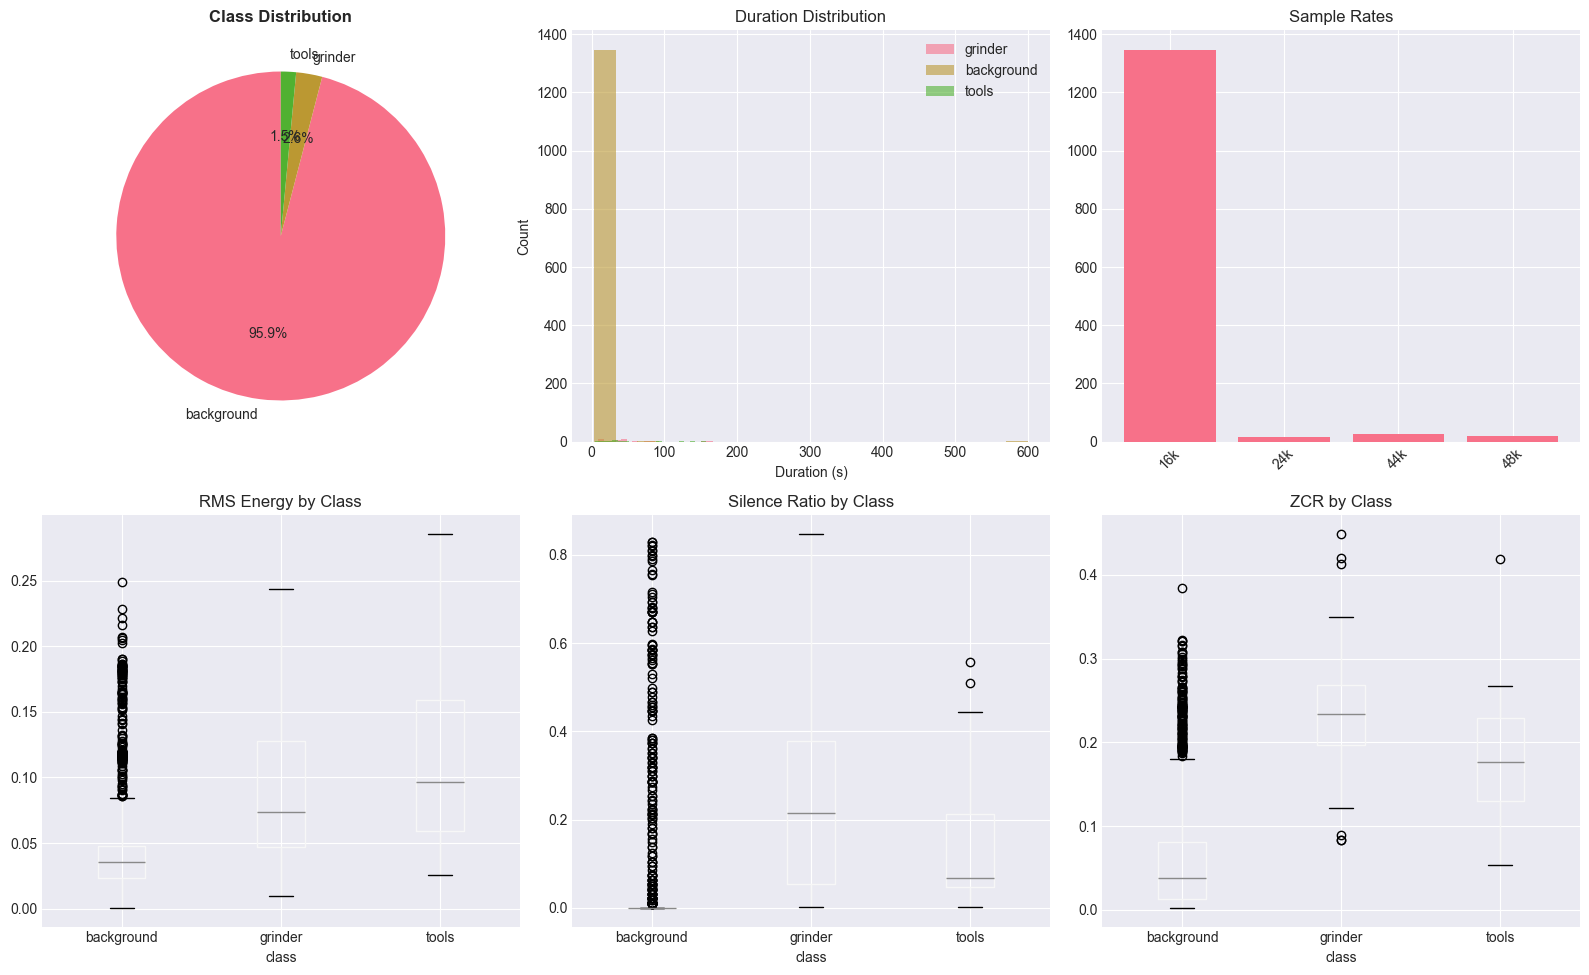

In [9]:
if len(df_success) > 0: 
    fig = plt.figure(figsize=(16, 10)) 
     
    # Pie chart 
    ax1 = plt.subplot(2, 3, 1) 
    class_counts = df_success['class'].value_counts() 
    ax1.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90) 
    ax1.set_title('Class Distribution', fontweight='bold') 
     
    # Duration histogram 
    ax2 = plt.subplot(2, 3, 2) 
    for cls in df_success['class'].unique(): 
        class_df = df_success[df_success['class'] == cls] 
        ax2.hist(class_df['duration'], alpha=0.6, label=cls, bins=20) 
    ax2.set_xlabel('Duration (s)') 
    ax2.set_ylabel('Count') 
    ax2.set_title('Duration Distribution') 
    ax2.legend() 
     
    # Sample rates 
    ax3 = plt.subplot(2, 3, 3) 
    sr_counts = df_success['sample_rate'].value_counts().sort_index() 
    ax3.bar(range(len(sr_counts)), sr_counts.values) 
    ax3.set_xticks(range(len(sr_counts))) 
    ax3.set_xticklabels([f'{sr//1000}k' for sr in sr_counts.index], rotation=45) 
    ax3.set_title('Sample Rates') 
     
    # RMS by class 
    ax4 = plt.subplot(2, 3, 4) 
    df_success.boxplot(column='rms_energy', by='class', ax=ax4) 
    ax4.set_title('RMS Energy by Class') 
    plt.suptitle('') 
     
    # Silence ratio 
    ax5 = plt.subplot(2, 3, 5) 
    df_success.boxplot(column='silence_ratio', by='class', ax=ax5) 
    ax5.set_title('Silence Ratio by Class') 
    plt.suptitle('') 
     
    # ZCR 
    ax6 = plt.subplot(2, 3, 6) 
    df_success.boxplot(column='zero_crossing_rate', by='class', ax=ax6) 
    ax6.set_title('ZCR by Class') 
    plt.suptitle('') 
     
    plt.tight_layout() 
    plt.savefig(FIGURES_DIR / '01_dataset_statistics.png', dpi=300) 
    print(f'✓ Saved: {FIGURES_DIR / "01_dataset_statistics.png"}') 
    plt.show()

## 8. Example Waveforms and Spectrograms

✓ Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/figures/01_waveforms_spectrograms.png


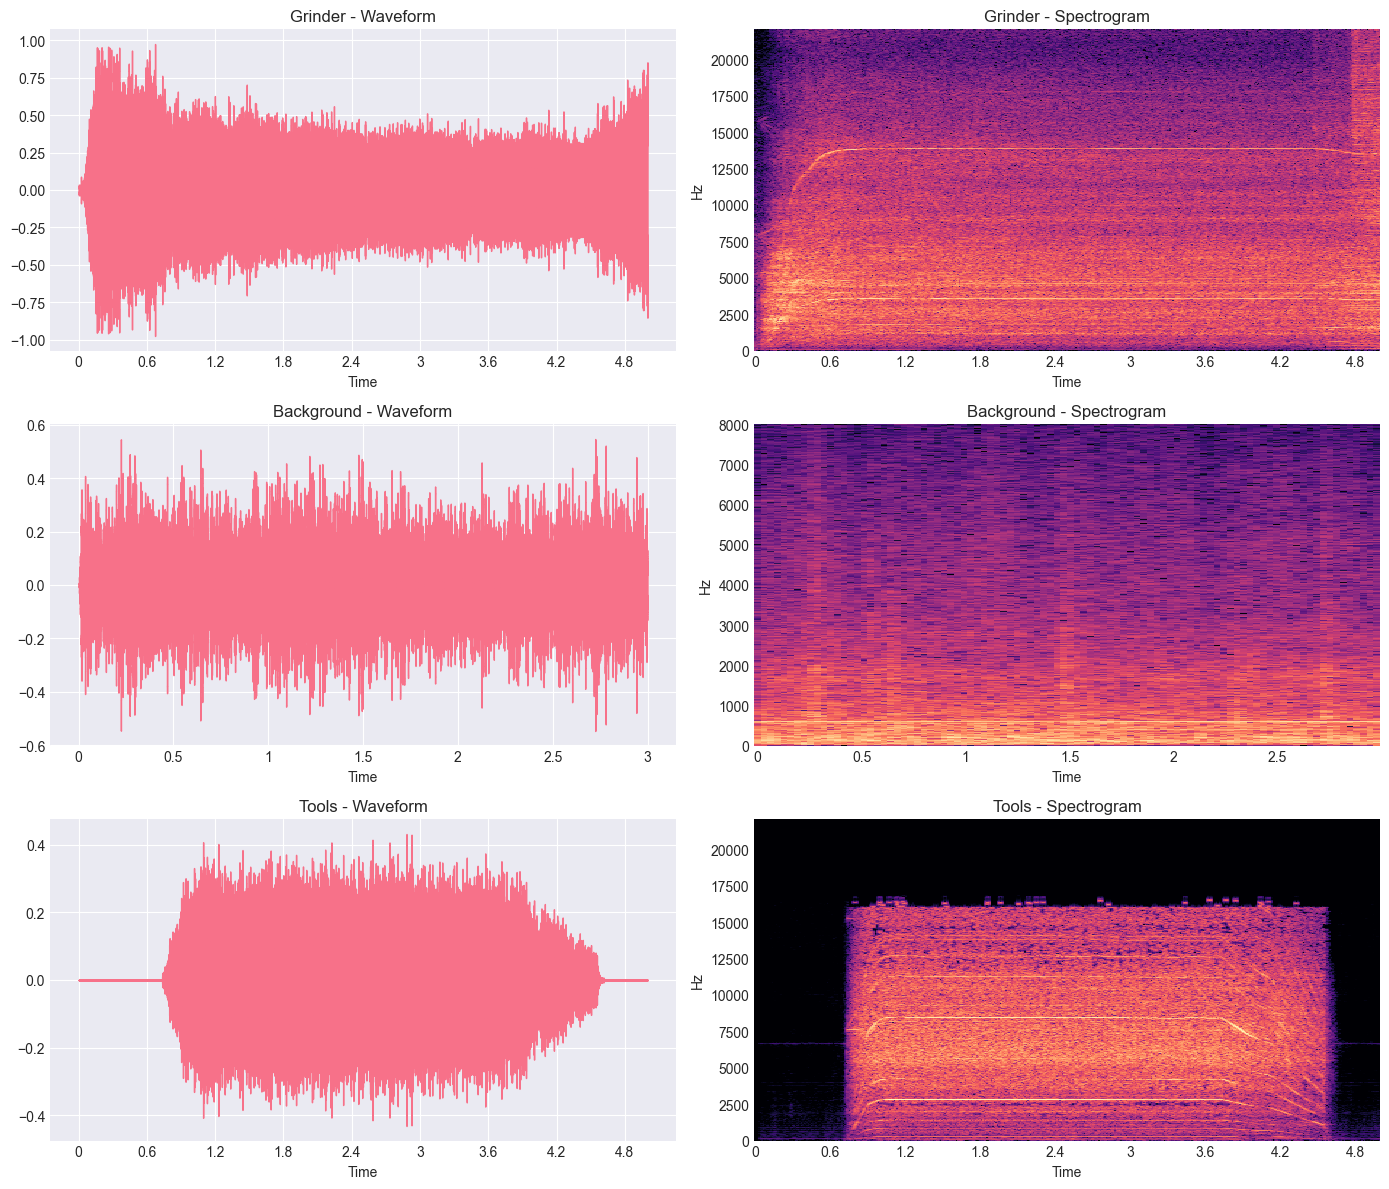

In [10]:
if len(df_success) > 0: 
    fig, axes = plt.subplots(len(CLASS_DIRS), 2, figsize=(14, 4*len(CLASS_DIRS))) 
    if len(CLASS_DIRS) == 1: 
        axes = axes.reshape(1, -1) 
     
    for idx, class_name in enumerate(CLASS_DIRS.keys()): 
        class_files = df_success[df_success['class'] == class_name] 
        if len(class_files) == 0: continue 
         
        example_file = Path(class_files.iloc[0]['filepath']) 
        audio, sr = librosa.load(example_file, sr=None, duration=5.0) 
         
        librosa.display.waveshow(audio, sr=sr, ax=axes[idx, 0]) 
        axes[idx, 0].set_title(f'{class_name.capitalize()} - Waveform') 
         
        D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max) 
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[idx, 1]) 
        axes[idx, 1].set_title(f'{class_name.capitalize()} - Spectrogram') 
     
    plt.tight_layout() 
    plt.savefig(FIGURES_DIR / '01_waveforms_spectrograms.png', dpi=300) 
    print(f'✓ Saved: {FIGURES_DIR / "01_waveforms_spectrograms.png"}') 
    plt.show()

### 4.5 Preprocessing Pipeline Visualization

This shows the step-by-step transformation of a raw grinder audio clip through
the preprocessing pipeline: resampling → high-pass filtering → normalization → segmentation.
We also show example augmentations applied to demonstrate data augmentation effects.


Using raw file: 0001Cut.wav


/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_20011/201287360.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y/1000)}' for y in yticks])
/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_20011/201287360.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y/1000)}' for y in yticks])
/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_20011/201287360.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y/1000)}' for y in yticks])
/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_20011/201287360.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

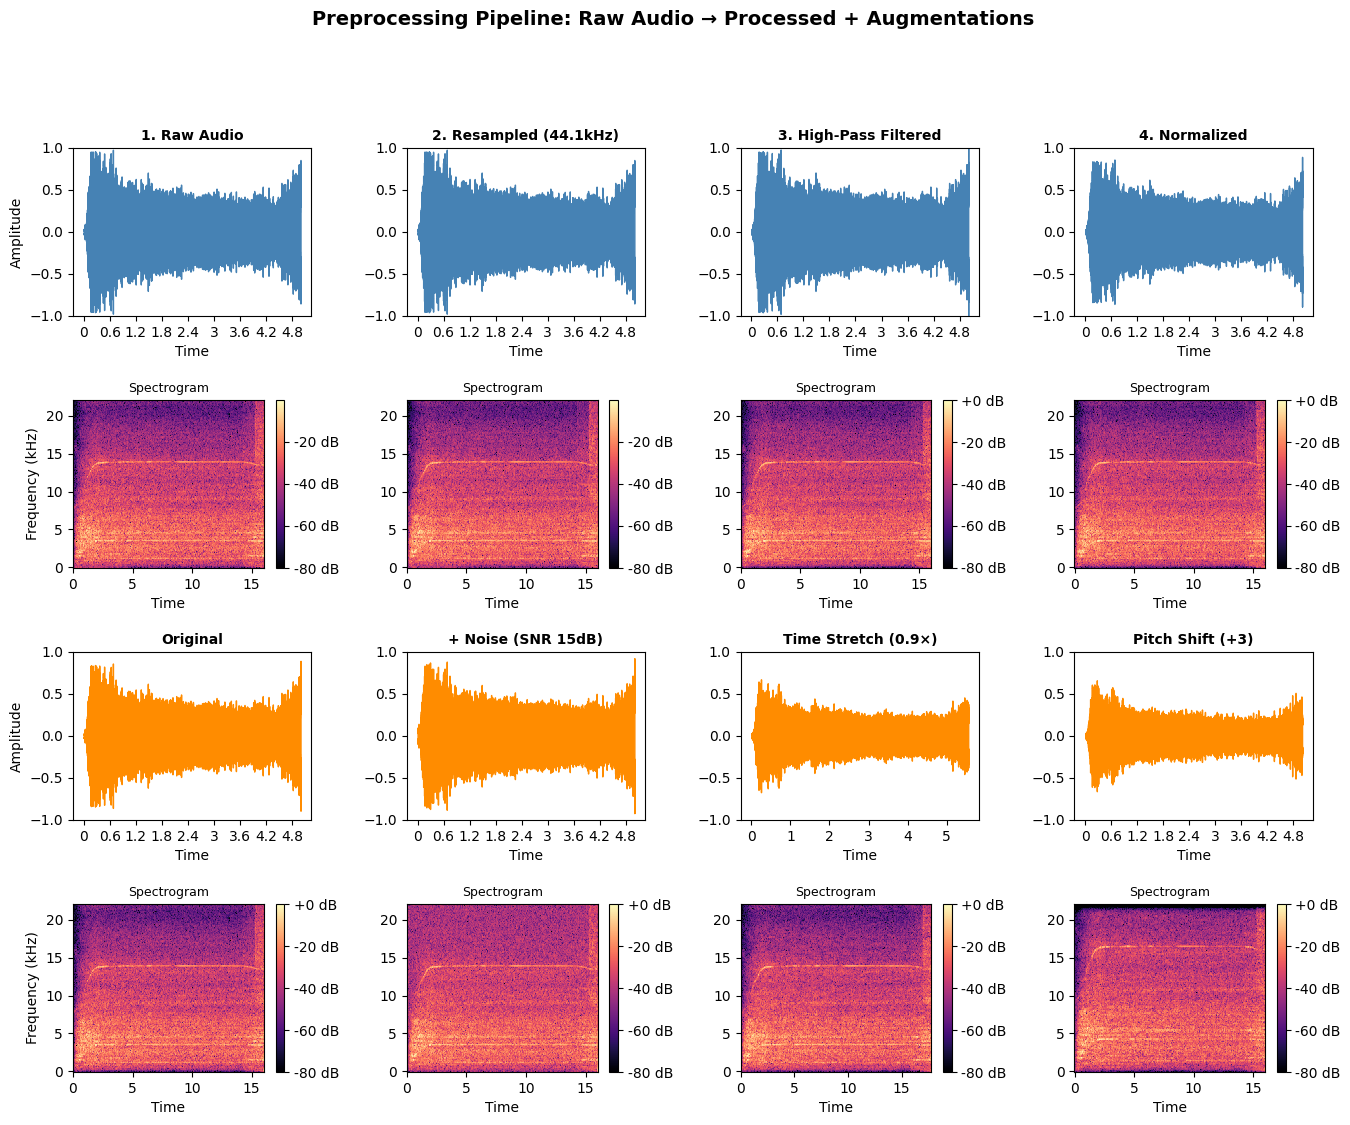

In [9]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal

# ========== PREPROCESSING FUNCTIONS ==========

def apply_highpass_filter(audio, sr, cutoff=80, order=5):
    """Apply high-pass Butterworth filter to remove low-frequency rumble."""
    nyquist = sr / 2
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    filtered = signal.filtfilt(b, a, audio)
    return filtered

def peak_normalize(audio, target_peak=0.89):
    """Peak normalization to avoid clipping."""
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        return audio * (target_peak / max_val)
    return audio

def add_noise(audio, snr_db=15):
    """Add white noise at specified SNR."""
    rms = np.sqrt(np.mean(audio**2))
    noise_rms = rms / (10**(snr_db / 20))
    noise = np.random.normal(0, noise_rms, size=audio.shape)
    return audio + noise

def time_stretch_audio(audio, rate=0.9):
    """Time stretch without changing pitch."""
    return librosa.effects.time_stretch(audio, rate=rate)

def pitch_shift_audio(audio, sr, steps=3):
    """Pitch shift by semitones."""
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=steps)

def gain_adjust(audio, db=4):
    """Adjust gain by dB."""
    factor = 10**(db / 20)
    return audio * factor

# ========== LOAD RAW GRINDER AUDIO ==========

RAW_DIR = DATA_DIR / "raw" if "DATA_DIR" in globals() else Path("../data/raw")
PROC_DIR = DATA_DIR / "processed" / "universal" if "DATA_DIR" in globals() else Path("../data/processed/universal")

# Try to find a raw grinder file
raw_grinder_files = list(RAW_DIR.glob("**/*Cut.*"))

if raw_grinder_files:
    raw_path = raw_grinder_files[0]
    print(f"Using raw file: {raw_path.name}")
    
    # Load original (no resampling)
    y_raw, sr_raw = librosa.load(raw_path, sr=None, duration=5)
    
    # ========== PREPROCESSING PIPELINE ==========
    
    # Step 1: Resample to 16kHz
    y_resampled = librosa.resample(y_raw, orig_sr=sr_raw, target_sr=44100)
    sr = 44100
    
    # Step 2: High-pass filter (80 Hz)
    y_filtered = apply_highpass_filter(y_resampled, sr, cutoff=80)
    
    # Step 3: Peak normalization
    y_normalized = peak_normalize(y_filtered, target_peak=0.89)
    
    # Step 4: Example augmentations (apply to normalized audio)
    y_noise = add_noise(y_normalized.copy(), snr_db=15)
    y_stretched = time_stretch_audio(y_normalized.copy(), rate=0.9)
    y_pitched = pitch_shift_audio(y_normalized.copy(), sr=sr, steps=3)
    y_gained = gain_adjust(y_normalized.copy(), db=4)
    
    # ========== VISUALIZATION ==========
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(4, 4, hspace=0.5, wspace=0.4)
    
    # Row 1: Preprocessing Pipeline (waveforms)
    stages = [
        ("1. Raw Audio", y_raw, sr_raw),
        ("2. Resampled (44.1kHz)", y_resampled, sr),
        ("3. High-Pass Filtered", y_filtered, sr),
        ("4. Normalized", y_normalized, sr),
    ]
    
    for col, (title, audio, sample_rate) in enumerate(stages):
        ax = fig.add_subplot(gs[0, col])
        librosa.display.waveshow(audio, sr=sample_rate, ax=ax, color='steelblue')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylim(-1, 1)
        if col == 0:
            ax.set_ylabel("Amplitude")
    
    # Row 2: Preprocessing Pipeline (spectrograms)
    for col, (title, audio, sample_rate) in enumerate(stages):
        ax = fig.add_subplot(gs[1, col])
        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(audio, n_fft=512, hop_length=160)),
            ref=np.max
        )
        img = librosa.display.specshow(
            D, x_axis='time', y_axis='hz', sr=sample_rate,
            ax=ax, cmap='magma'
        )
        ax.set_title(f"Spectrogram", fontsize=9)
        
        # Convert Hz to kHz on y-axis
        yticks = ax.get_yticks()
        ax.set_yticklabels([f'{int(y/1000)}' for y in yticks])
        
        if col == 0:
            ax.set_ylabel("Frequency (kHz)")
        else:
            ax.set_ylabel("")
            
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
    
    # Row 3: Augmentation Examples (waveforms)
    augmentations = [
        ("Original", y_normalized),
        ("+ Noise (SNR 15dB)", y_noise),
        ("Time Stretch (0.9×)", y_stretched),
        ("Pitch Shift (+3)", y_pitched),
    ]
    
    for col, (title, audio) in enumerate(augmentations):
        ax = fig.add_subplot(gs[2, col])
        librosa.display.waveshow(audio, sr=sr, ax=ax, color='darkorange')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylim(-1, 1)
        if col == 0:
            ax.set_ylabel("Amplitude")
    
    # Row 4: Augmentation Examples (spectrograms)
    for col, (title, audio) in enumerate(augmentations):
        ax = fig.add_subplot(gs[3, col])
        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(audio, n_fft=512, hop_length=160)),
            ref=np.max
        )
        img = librosa.display.specshow(
            D, x_axis='time', y_axis='hz', sr=sr,
            ax=ax, cmap='magma'
        )
        ax.set_title(f"Spectrogram", fontsize=9)
        
        # Convert Hz to kHz on y-axis
        yticks = ax.get_yticks()
        ax.set_yticklabels([f'{int(y/1000)}' for y in yticks])
        
        if col == 0:
            ax.set_ylabel("Frequency (kHz)")
        else:
            ax.set_ylabel("")
            
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
    
    plt.suptitle(
        "Preprocessing Pipeline: Raw Audio → Processed + Augmentations",
        fontsize=14, fontweight='bold', y=0.995
    )
    plt.show()
      
else:
    print("No raw grinder files found. Please check your data/raw directory structure.")
    print(f"Searched in: {RAW_DIR}")


/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_17529/3962541802.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_yticklabels([f'{int(y/1000)}' for y in yticks])
/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_17529/3962541802.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_yticklabels([f'{int(y/1000)}' for y in yticks])


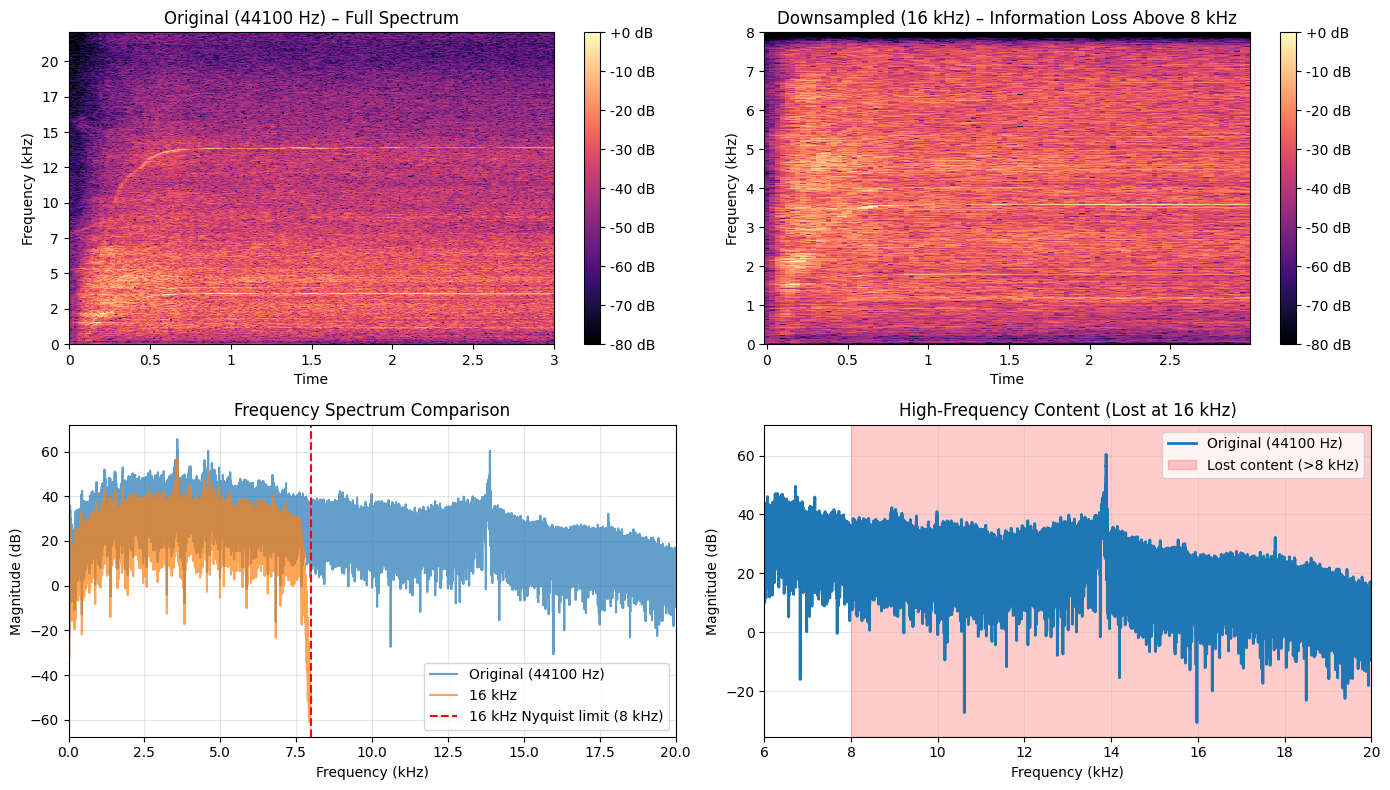


📊 Energy Analysis:
   Original sample rate: 44100 Hz
   Energy above 8 kHz: 11.41% of total signal energy

⚠️  If this percentage is >5%, consider using 44.1 kHz sampling!


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load same grinder file at both sample rates
raw_grinder_files = list(RAW_DIR.glob("**/*Cut.*"))

if raw_grinder_files:
    raw_path = raw_grinder_files[0]
    
    # Load at original rate and at 16 kHz
    y_original, sr_original = librosa.load(raw_path, sr=None, duration=3)
    y_16k, sr_16k = librosa.load(raw_path, sr=44100, duration=3)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Original sample rate spectrogram
    D_orig = librosa.amplitude_to_db(
        np.abs(librosa.stft(y_original, n_fft=2048, hop_length=512)),
        ref=np.max
    )
    img1 = librosa.display.specshow(
        D_orig, x_axis='time', y_axis='hz', sr=sr_original,
        ax=axes[0, 0], cmap='magma'
    )
    axes[0, 0].set_title(f"Original ({sr_original} Hz) – Full Spectrum")
    axes[0, 0].set_ylabel("Frequency (kHz)")
    yticks = axes[0, 0].get_yticks()
    axes[0, 0].set_yticklabels([f'{int(y/1000)}' for y in yticks])
    fig.colorbar(img1, ax=axes[0, 0], format='%+2.0f dB')
    
    # 16 kHz spectrogram
    D_16k = librosa.amplitude_to_db(
        np.abs(librosa.stft(y_16k, n_fft=2048, hop_length=512)),
        ref=np.max
    )
    img2 = librosa.display.specshow(
        D_16k, x_axis='time', y_axis='hz', sr=sr_16k,
        ax=axes[0, 1], cmap='magma'
    )
    axes[0, 1].set_title("Downsampled (16 kHz) – Information Loss Above 8 kHz")
    axes[0, 1].set_ylabel("Frequency (kHz)")
    yticks = axes[0, 1].get_yticks()
    axes[0, 1].set_yticklabels([f'{int(y/1000)}' for y in yticks])
    fig.colorbar(img2, ax=axes[0, 1], format='%+2.0f dB')
    
    # Frequency spectrum comparison (averaged over time)
    freqs_orig, spectrum_orig = np.fft.rfftfreq(len(y_original), 1/sr_original), np.abs(np.fft.rfft(y_original))
    freqs_16k, spectrum_16k = np.fft.rfftfreq(len(y_16k), 1/sr_16k), np.abs(np.fft.rfft(y_16k))
    
    axes[1, 0].plot(freqs_orig/1000, 20*np.log10(spectrum_orig + 1e-10), label=f'Original ({sr_original} Hz)', alpha=0.7)
    axes[1, 0].plot(freqs_16k/1000, 20*np.log10(spectrum_16k + 1e-10), label='16 kHz', alpha=0.7)
    axes[1, 0].axvline(x=8, color='red', linestyle='--', label='16 kHz Nyquist limit (8 kHz)')
    axes[1, 0].set_xlim(0, 20)
    axes[1, 0].set_xlabel("Frequency (kHz)")
    axes[1, 0].set_ylabel("Magnitude (dB)")
    axes[1, 0].set_title("Frequency Spectrum Comparison")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Highlight high-frequency region
    axes[1, 1].plot(freqs_orig/1000, 20*np.log10(spectrum_orig + 1e-10), label=f'Original ({sr_original} Hz)', linewidth=2)
    axes[1, 1].axvspan(8, 22, alpha=0.2, color='red', label='Lost content (>8 kHz)')
    axes[1, 1].set_xlim(6, 20)
    axes[1, 1].set_xlabel("Frequency (kHz)")
    axes[1, 1].set_ylabel("Magnitude (dB)")
    axes[1, 1].set_title("High-Frequency Content (Lost at 16 kHz)")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate energy in high-frequency band
    high_freq_mask = freqs_orig > 8000
    total_energy = np.sum(spectrum_orig**2)
    high_freq_energy = np.sum(spectrum_orig[high_freq_mask]**2)
    pct_high_freq = (high_freq_energy / total_energy) * 100
    
    print(f"\n📊 Energy Analysis:")
    print(f"   Original sample rate: {sr_original} Hz")
    print(f"   Energy above 8 kHz: {pct_high_freq:.2f}% of total signal energy")
    print(f"\n⚠️  If this percentage is >5%, consider using 44.1 kHz sampling!")



📊 Frequency Band Energy Analysis:

Grinder     :
  0-2 kHz:      19.6%
  2-8 kHz:      69.4%
  8-16 kHz:     11.0% ⚠️  LOST at 16 kHz
  16-22 kHz:     0.0%



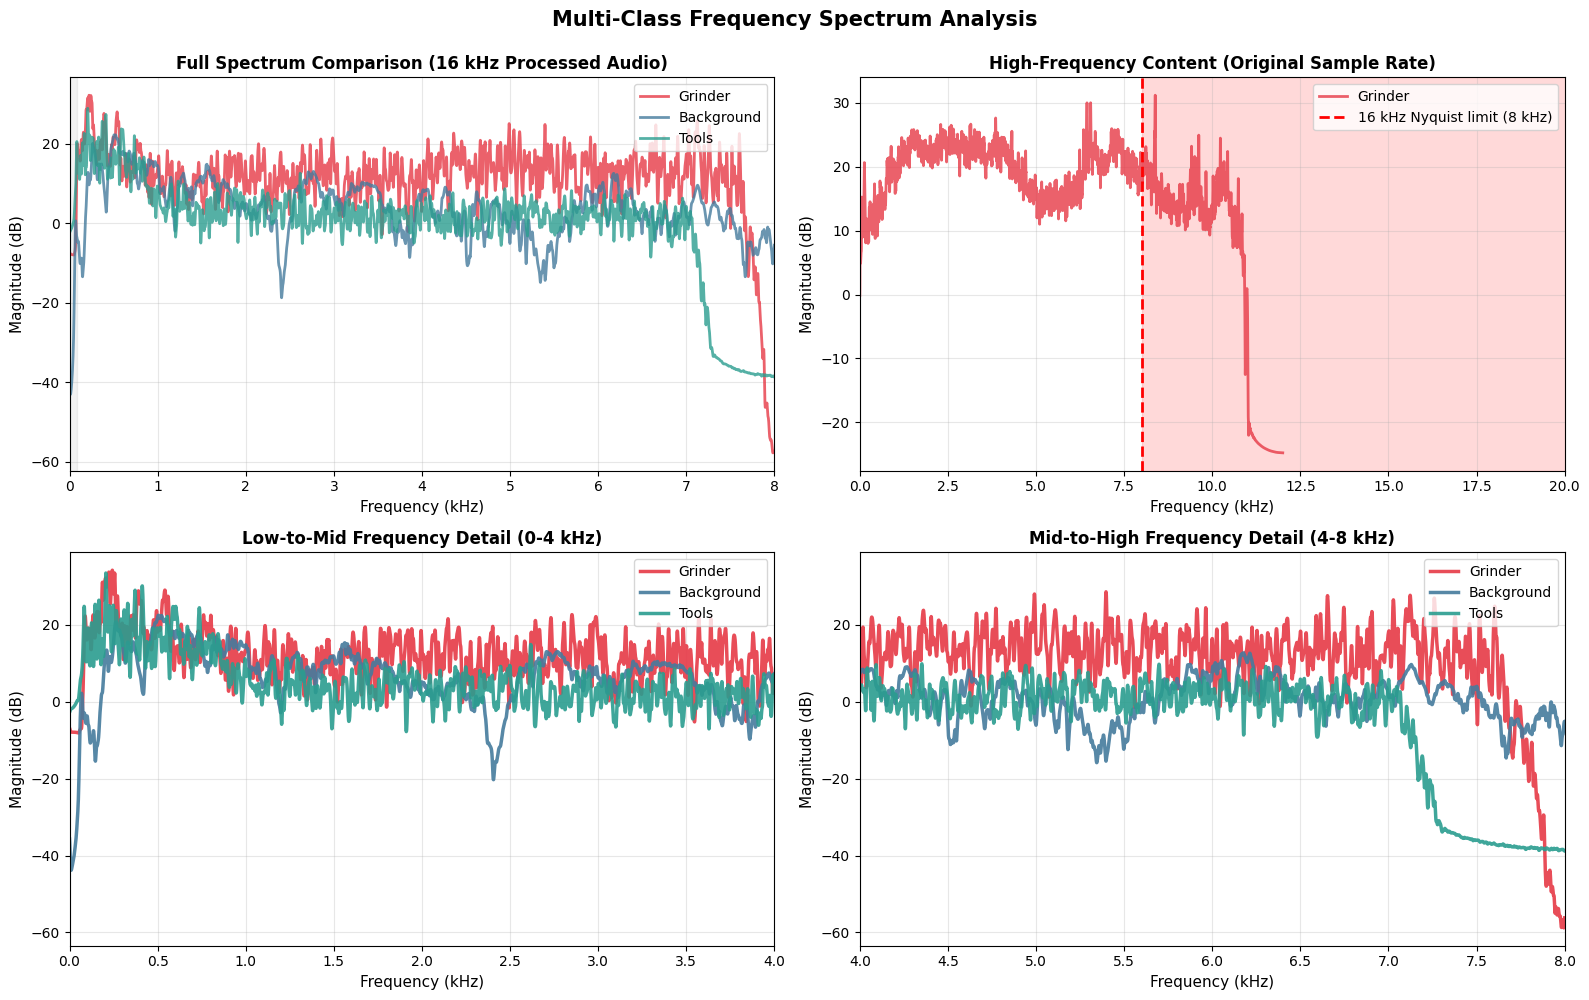

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load one example from each class
PROC_DIR = DATA_DIR / "processed" / "universal" if "DATA_DIR" in globals() else Path("../data/processed/universal")

example_files = {}
for class_name in ["grinder", "background", "tools"]:
    files = list(PROC_DIR.glob(f"{class_name}_*.wav"))
    if files:
        example_files[class_name] = files[0]

if len(example_files) == 3:
    # Also try to find raw versions for comparison
    RAW_DIR = DATA_DIR / "raw" if "DATA_DIR" in globals() else Path("../data/raw")
    raw_grinder = list(RAW_DIR.glob("**/grinder*.mp3")) + list(RAW_DIR.glob("**/grinder*.wav")) + \
                  list(RAW_DIR.glob("**/angle*.mp3")) + list(RAW_DIR.glob("**/angle*.wav"))
    
    # Determine if we have high sample rate raw data
    use_raw = len(raw_grinder) > 0
    
    if use_raw:
        y_test, sr_test = librosa.load(raw_grinder[0], sr=None, duration=3)
        use_high_sr = sr_test > 44100
    else:
        use_high_sr = False
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Color scheme for classes
    colors = {
        "grinder": "#E63946",      # Red
        "background": "#457B9D",   # Blue
        "tools": "#2A9D8F"         # Teal
    }
    
    # Store spectra for comparison
    spectra = {}
    
    # ========== LOAD AND COMPUTE SPECTRA ==========
    
    for cls, filepath in example_files.items():
        # Load at 16 kHz (processed)
        y_16k, sr_16k = librosa.load(filepath, sr=44100)
        
        # Compute FFT and frequency spectrum
        spectrum_16k = np.abs(np.fft.rfft(y_16k))
        freqs_16k = np.fft.rfftfreq(len(y_16k), 1/sr_16k)
        
        spectra[cls] = {
            '16k': (freqs_16k, spectrum_16k),
        }
        
        # If high sample rate raw data available, load original
        if use_high_sr:
            # Try to find corresponding raw file for this class
            raw_files = list(RAW_DIR.glob(f"**/{cls}*.mp3")) + list(RAW_DIR.glob(f"**/{cls}*.wav"))
            if not raw_files and cls == "grinder":
                raw_files = list(RAW_DIR.glob("**/angle*.mp3")) + list(RAW_DIR.glob("**/angle*.wav"))
            
            if raw_files:
                y_orig, sr_orig = librosa.load(raw_files[0], sr=None, duration=3)
                spectrum_orig = np.abs(np.fft.rfft(y_orig))
                freqs_orig = np.fft.rfftfreq(len(y_orig), 1/sr_orig)
                spectra[cls]['original'] = (freqs_orig, spectrum_orig)
    
    # ========== PLOT 1: Full Spectrum Comparison (16 kHz) ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        # Convert to dB
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        # Smooth for cleaner visualization
        from scipy.ndimage import gaussian_filter1d
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=5)
        
        axes[0, 0].plot(
            freqs/1000, 
            spectrum_smooth, 
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2,
            alpha=0.8
        )
    
    axes[0, 0].set_xlim(0, 8)
    axes[0, 0].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[0, 0].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[0, 0].set_title("Full Spectrum Comparison (16 kHz Processed Audio)", fontsize=12, fontweight='bold')
    axes[0, 0].legend(loc='upper right', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvspan(0, 0.08, alpha=0.1, color='gray', label='High-pass filtered (<80 Hz)')
    
    # ========== PLOT 2: High-Frequency Detail (if available) ==========
    
    if use_high_sr and 'original' in spectra['grinder']:
        for cls in ["grinder", "background", "tools"]:
            if 'original' in spectra[cls]:
                freqs, spectrum = spectra[cls]['original']
                spectrum_db = 20 * np.log10(spectrum + 1e-10)
                spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=10)
                
                axes[0, 1].plot(
                    freqs/1000,
                    spectrum_smooth,
                    label=cls.capitalize(),
                    color=colors[cls],
                    linewidth=2,
                    alpha=0.8
                )
        
        axes[0, 1].axvline(x=8, color='red', linestyle='--', linewidth=2, label='16 kHz Nyquist limit (8 kHz)')
        axes[0, 1].axvspan(8, 22, alpha=0.15, color='red')
        axes[0, 1].set_xlim(0, 20)
        axes[0, 1].set_xlabel("Frequency (kHz)", fontsize=11)
        axes[0, 1].set_ylabel("Magnitude (dB)", fontsize=11)
        axes[0, 1].set_title("High-Frequency Content (Original Sample Rate)", fontsize=12, fontweight='bold')
        axes[0, 1].legend(loc='upper right', fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Calculate energy in different bands for each class
        print("\n📊 Frequency Band Energy Analysis:\n")
        for cls in ["grinder", "background", "tools"]:
            if 'original' in spectra[cls]:
                freqs, spectrum = spectra[cls]['original']
                
                # Energy in different bands
                low_mask = (freqs < 2000)
                mid_mask = (freqs >= 2000) & (freqs < 8000)
                high_mask = (freqs >= 8000) & (freqs < 16000)
                very_high_mask = (freqs >= 16000)
                
                total_energy = np.sum(spectrum**2)
                low_energy = np.sum(spectrum[low_mask]**2) / total_energy * 100
                mid_energy = np.sum(spectrum[mid_mask]**2) / total_energy * 100
                high_energy = np.sum(spectrum[high_mask]**2) / total_energy * 100
                very_high_energy = np.sum(spectrum[very_high_mask]**2) / total_energy * 100
                
                print(f"{cls.capitalize():12s}:")
                print(f"  0-2 kHz:     {low_energy:5.1f}%")
                print(f"  2-8 kHz:     {mid_energy:5.1f}%")
                print(f"  8-16 kHz:    {high_energy:5.1f}% {'⚠️  LOST at 16 kHz' if high_energy > 5 else ''}")
                print(f"  16-22 kHz:   {very_high_energy:5.1f}%")
                print()
    else:
        axes[0, 1].text(
            0.5, 0.5,
            "High sample rate raw data\nnot available\n\nLoad original files at >16 kHz\nto see high-frequency content",
            ha='center', va='center',
            fontsize=11, color='gray'
        )
        axes[0, 1].set_title("High-Frequency Content (Not Available)", fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
    
    # ========== PLOT 3: Low-to-Mid Frequency Detail ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=3)
        
        axes[1, 0].plot(
            freqs/1000,
            spectrum_smooth,
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2.5,
            alpha=0.9
        )
    
    axes[1, 0].set_xlim(0, 4)
    axes[1, 0].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[1, 0].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[1, 0].set_title("Low-to-Mid Frequency Detail (0-4 kHz)", fontsize=12, fontweight='bold')
    axes[1, 0].legend(loc='upper right', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # ========== PLOT 4: Mid-to-High Frequency Detail ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=3)
        
        axes[1, 1].plot(
            freqs/1000,
            spectrum_smooth,
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2.5,
            alpha=0.9
        )
    
    axes[1, 1].set_xlim(4, 8)
    axes[1, 1].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[1, 1].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[1, 1].set_title("Mid-to-High Frequency Detail (4-8 kHz)", fontsize=12, fontweight='bold')
    axes[1, 1].legend(loc='upper right', fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(
        "Multi-Class Frequency Spectrum Analysis",
        fontsize=15, fontweight='bold', y=0.995
    )
    plt.tight_layout()
    plt.show()
    
else:
    print("Could not find example files for all three classes.")
    print(f"Found: {list(example_files.keys())}")


Found raw files for: ['grinder']
  grinder: loaded at 44100 Hz

📊 Frequency Band Energy Analysis (Original Sample Rate):

Class        0-2 kHz    2-8 kHz    8-16 kHz     16-22 kHz   
------------------------------------------------------------
Grinder        11.5%      77.0%      11.2%   *     0.3%

* = Significant energy (>5%) in band that would be lost at 16 kHz

💡 Interpretation:
   - If grinder has significantly MORE energy >8 kHz than background/tools,
     consider using 44.1 kHz sampling for better discrimination.
   - If all classes have similar energy >8 kHz, 16 kHz is sufficient.



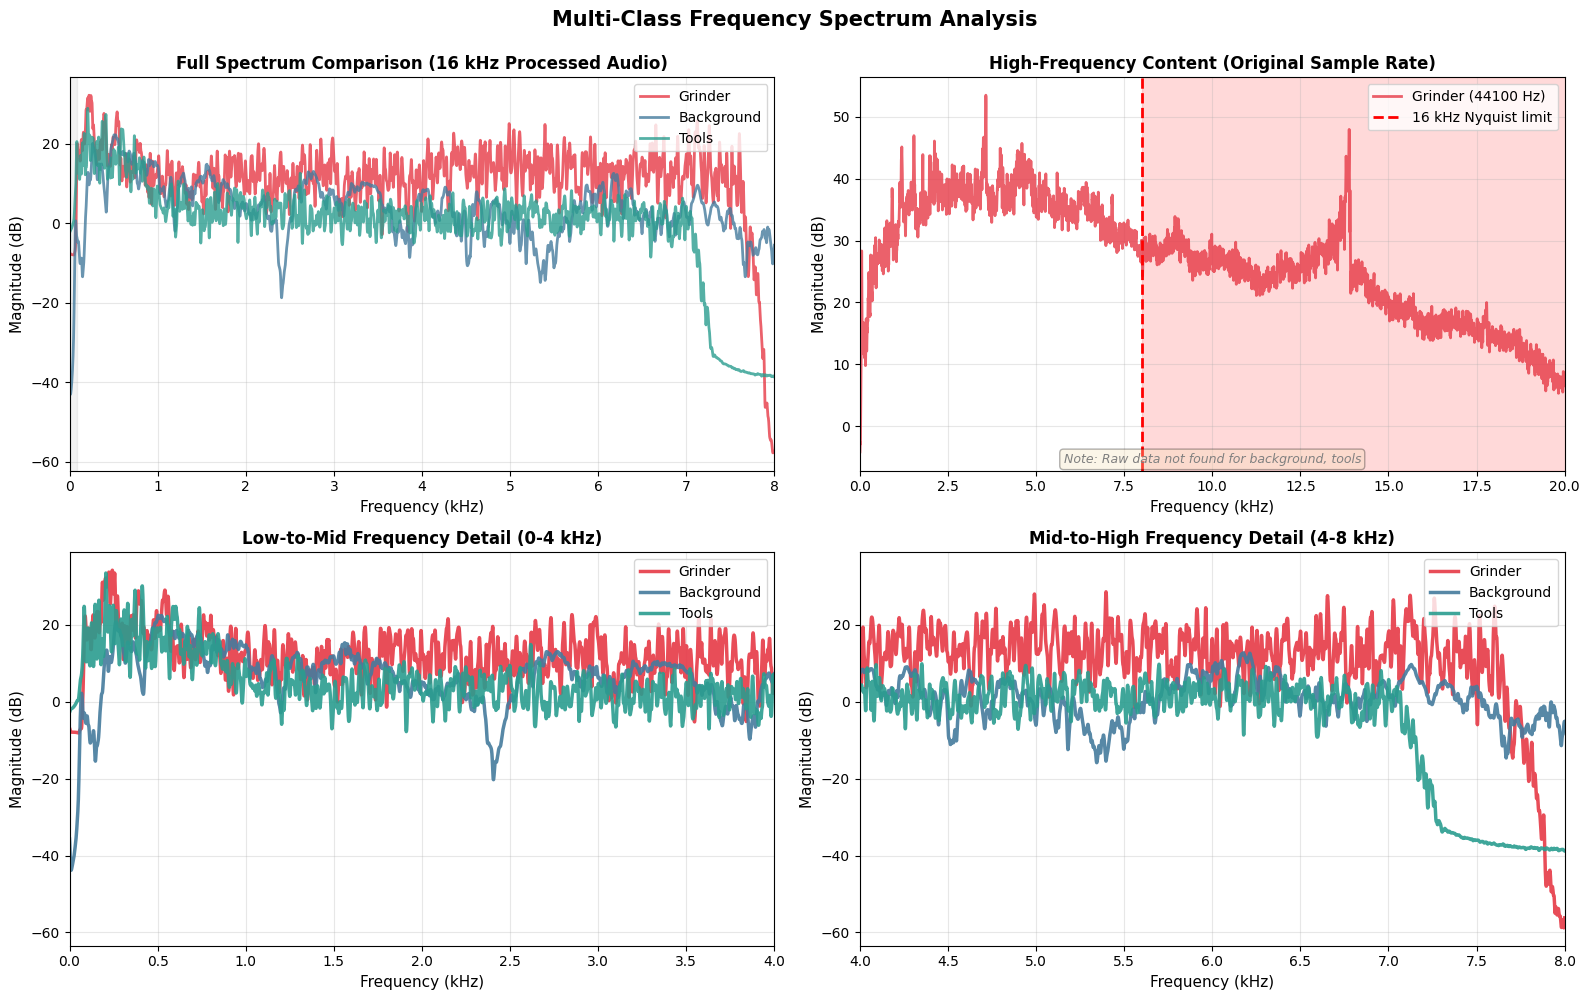

In [4]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

# Load one example from each class
PROC_DIR = DATA_DIR / "processed" / "universal" if "DATA_DIR" in globals() else Path("../data/processed/universal")

example_files = {}
for class_name in ["grinder", "background", "tools"]:
    files = list(PROC_DIR.glob(f"{class_name}_*.wav"))
    if files:
        example_files[class_name] = files[0]

if len(example_files) == 3:
    # Try to find raw versions for ALL classes
    RAW_DIR = DATA_DIR / "raw" if "DATA_DIR" in globals() else Path("../data/raw")
    
    raw_files_by_class = {}
    for class_name in ["grinder", "background", "tools"]:
        raw_candidates = []
        
        if class_name == "grinder":
            # Multiple possible naming patterns for grinder
            raw_candidates = list(RAW_DIR.glob("**/*Cut.*"))
        else:
            # Standard naming for background and tools
            raw_candidates = (list(RAW_DIR.glob(f"**/{class_name}*.mp3")) + 
                            list(RAW_DIR.glob(f"**/{class_name}*.wav")))
        
        if raw_candidates:
            raw_files_by_class[class_name] = raw_candidates[0]
    
    print(f"Found raw files for: {list(raw_files_by_class.keys())}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Color scheme for classes
    colors = {
        "grinder": "#E63946",      # Red
        "background": "#457B9D",   # Blue
        "tools": "#2A9D8F"         # Teal
    }
    
    # Store spectra for comparison
    spectra = {}
    
    # ========== LOAD AND COMPUTE SPECTRA ==========
    
    for cls, filepath in example_files.items():
        # Load at 16 kHz (processed)
        y_16k, sr_16k = librosa.load(filepath, sr=16000)
        
        # Compute FFT and frequency spectrum
        spectrum_16k = np.abs(np.fft.rfft(y_16k))
        freqs_16k = np.fft.rfftfreq(len(y_16k), 1/sr_16k)
        
        spectra[cls] = {
            '16k': (freqs_16k, spectrum_16k),
        }
        
        # Load original high sample rate if available
        if cls in raw_files_by_class:
            y_orig, sr_orig = librosa.load(raw_files_by_class[cls], sr=None, duration=3)
            spectrum_orig = np.abs(np.fft.rfft(y_orig))
            freqs_orig = np.fft.rfftfreq(len(y_orig), 1/sr_orig)
            spectra[cls]['original'] = (freqs_orig, spectrum_orig, sr_orig)
            print(f"  {cls}: loaded at {sr_orig} Hz")
    
    # ========== PLOT 1: Full Spectrum Comparison (16 kHz) ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        # Convert to dB
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        # Smooth for cleaner visualization
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=5)
        
        axes[0, 0].plot(
            freqs/1000, 
            spectrum_smooth, 
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2,
            alpha=0.8
        )
    
    axes[0, 0].set_xlim(0, 8)
    axes[0, 0].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[0, 0].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[0, 0].set_title("Full Spectrum Comparison (16 kHz Processed Audio)", fontsize=12, fontweight='bold')
    axes[0, 0].legend(loc='upper right', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvspan(0, 0.08, alpha=0.1, color='gray', label='High-pass filtered (<80 Hz)')
    
    # ========== PLOT 2: High-Frequency Detail (ALL CLASSES) ==========
    
    high_sr_available = any('original' in spectra[cls] for cls in ["grinder", "background", "tools"])
    
    if high_sr_available:
        classes_plotted = []
        
        for cls in ["grinder", "background", "tools"]:
            if 'original' in spectra[cls]:
                freqs, spectrum, sr_orig = spectra[cls]['original']
                spectrum_db = 20 * np.log10(spectrum + 1e-10)
                spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=10)
                
                axes[0, 1].plot(
                    freqs/1000,
                    spectrum_smooth,
                    label=f"{cls.capitalize()} ({sr_orig} Hz)",
                    color=colors[cls],
                    linewidth=2,
                    alpha=0.8
                )
                classes_plotted.append(cls)
        
        axes[0, 1].axvline(x=8, color='red', linestyle='--', linewidth=2, label='16 kHz Nyquist limit')
        axes[0, 1].axvspan(8, 22, alpha=0.15, color='red')
        axes[0, 1].set_xlim(0, 20)
        axes[0, 1].set_xlabel("Frequency (kHz)", fontsize=11)
        axes[0, 1].set_ylabel("Magnitude (dB)", fontsize=11)
        axes[0, 1].set_title("High-Frequency Content (Original Sample Rate)", fontsize=12, fontweight='bold')
        axes[0, 1].legend(loc='upper right', fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Add annotation about missing classes
        missing = [c for c in ["grinder", "background", "tools"] if c not in classes_plotted]
        if missing:
            axes[0, 1].text(
                0.5, 0.02,
                f"Note: Raw data not found for {', '.join(missing)}",
                transform=axes[0, 1].transAxes,
                ha='center', fontsize=9, style='italic', color='gray',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3)
            )
        
        # Calculate energy in different bands for EACH CLASS
        print("\n📊 Frequency Band Energy Analysis (Original Sample Rate):\n")
        print(f"{'Class':<12} {'0-2 kHz':<10} {'2-8 kHz':<10} {'8-16 kHz':<12} {'16-22 kHz':<12}")
        print("-" * 60)
        
        for cls in ["grinder", "background", "tools"]:
            if 'original' in spectra[cls]:
                freqs, spectrum, sr_orig = spectra[cls]['original']
                
                # Energy in different bands
                low_mask = (freqs < 2000)
                mid_mask = (freqs >= 2000) & (freqs < 8000)
                high_mask = (freqs >= 8000) & (freqs < 16000)
                very_high_mask = (freqs >= 16000)
                
                total_energy = np.sum(spectrum**2)
                low_energy = np.sum(spectrum[low_mask]**2) / total_energy * 100
                mid_energy = np.sum(spectrum[mid_mask]**2) / total_energy * 100
                high_energy = np.sum(spectrum[high_mask]**2) / total_energy * 100
                very_high_energy = np.sum(spectrum[very_high_mask]**2) / total_energy * 100
                
                print(f"{cls.capitalize():<12} {low_energy:>6.1f}%    {mid_energy:>6.1f}%    "
                      f"{high_energy:>6.1f}%{'*' if high_energy > 5 else ' ':>4}  {very_high_energy:>6.1f}%")
        
        print("\n* = Significant energy (>5%) in band that would be lost at 16 kHz")
        print("\n💡 Interpretation:")
        print("   - If grinder has significantly MORE energy >8 kHz than background/tools,")
        print("     consider using 44.1 kHz sampling for better discrimination.")
        print("   - If all classes have similar energy >8 kHz, 16 kHz is sufficient.\n")
        
    else:
        axes[0, 1].text(
            0.5, 0.5,
            "High sample rate raw data\nnot available for any class\n\nPlace original audio files\nin data/raw/ to analyze\nhigh-frequency content",
            ha='center', va='center',
            fontsize=11, color='gray'
        )
        axes[0, 1].set_title("High-Frequency Content (Not Available)", fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
    
    # ========== PLOT 3: Low-to-Mid Frequency Detail ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=3)
        
        axes[1, 0].plot(
            freqs/1000,
            spectrum_smooth,
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2.5,
            alpha=0.9
        )
    
    axes[1, 0].set_xlim(0, 4)
    axes[1, 0].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[1, 0].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[1, 0].set_title("Low-to-Mid Frequency Detail (0-4 kHz)", fontsize=12, fontweight='bold')
    axes[1, 0].legend(loc='upper right', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # ========== PLOT 4: Mid-to-High Frequency Detail ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=3)
        
        axes[1, 1].plot(
            freqs/1000,
            spectrum_smooth,
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2.5,
            alpha=0.9
        )
    
    axes[1, 1].set_xlim(4, 8)
    axes[1, 1].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[1, 1].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[1, 1].set_title("Mid-to-High Frequency Detail (4-8 kHz)", fontsize=12, fontweight='bold')
    axes[1, 1].legend(loc='upper right', fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(
        "Multi-Class Frequency Spectrum Analysis",
        fontsize=15, fontweight='bold', y=0.995
    )
    plt.tight_layout()
    plt.show()
    
else:
    print("Could not find example files for all three classes.")
    print(f"Found: {list(example_files.keys())}")


🔍 Searching for high sample rate (>16 kHz) raw audio files...

Searching for grinder:
  Found 1 potential files
  ✓ Selected: Cut2.wav (44100 Hz)

Searching for background:
  Found 0 potential files
  ✗ No files found with sample rate >16 kHz

Searching for tools:
  Found 1 potential files
  ✓ Selected: drill-200178.mp3 (44100 Hz)


📁 Final selection: ['grinder', 'tools']

📊 Frequency Band Energy Analysis (Original Sample Rate):

Class        Sample Rate  0-2 kHz    2-8 kHz    8-16 kHz     16-22 kHz   
------------------------------------------------------------------------
Grinder      44100          37.0%      42.4%      14.7%   *     5.9%
Background   16 kHz only  —          —          —            —           
Tools        44100           8.8%      66.0%      24.4%   *     0.8%

* = Significant energy (>5%) in 8-16 kHz band (lost at 16 kHz sampling)

💡 Decision Guide:
   ✓ If grinder has >10% energy in 8-16 kHz AND other classes have <5%:
     → Strong case for 44.1 kHz (discrimina

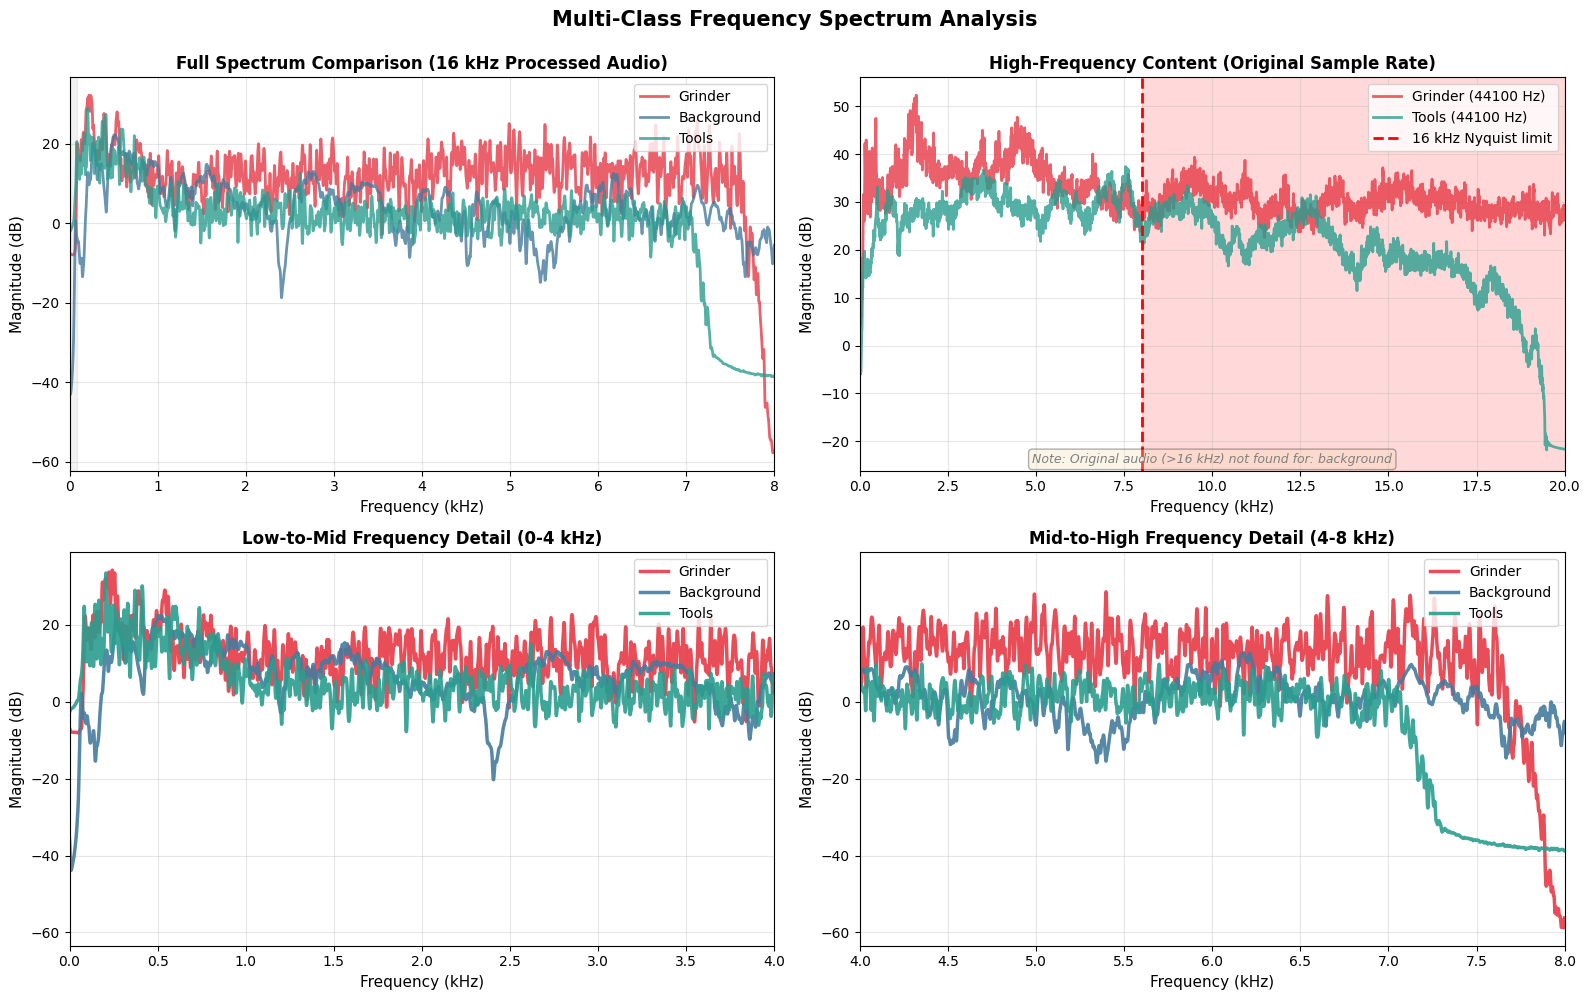

In [8]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

# Load one example from each class
PROC_DIR = DATA_DIR / "processed" / "universal" if "DATA_DIR" in globals() else Path("../data/processed/universal")

example_files = {}
for class_name in ["grinder", "background", "tools"]:
    files = list(PROC_DIR.glob(f"{class_name}_*.wav"))
    if files:
        example_files[class_name] = files[0]

if len(example_files) == 3:
    # Try to find raw versions for ALL classes
    RAW_DIR = DATA_DIR / "raw" if "DATA_DIR" in globals() else Path("../data/raw")
    
    raw_files_by_class = {}
    
    print("🔍 Searching for high sample rate (>16 kHz) raw audio files...\n")
    
    for class_name in ["grinder", "background", "tools"]:
        print(f"Searching for {class_name}:")
        
        # Broader search patterns
        if class_name == "grinder":
            search_patterns = [
                "**/*Cut2*.wav"
               
            ]
        elif class_name == "background":
            search_patterns = [
                "**/background*.mp3", "**/background*.wav",
                "**/bg*.mp3", "**/bg*.wav",
                "**/ambient*.mp3", "**/ambient*.wav",
                "**/noise*.mp3", "**/noise*.wav"
            ]
        else:  # tools
            search_patterns = [
                "**/tools*.mp3", "**/tools*.wav",
                "**/tool*.mp3", "**/tool*.wav",
                "**/drill*.mp3", "**/drill*.wav",
                "**/saw*.mp3", "**/saw*.wav"
            ]
        
        # Find all matching files
        candidates = []
        for pattern in search_patterns:
            candidates.extend(RAW_DIR.glob(pattern))
        
        print(f"  Found {len(candidates)} potential files")
        
        # Check sample rates and pick highest
        best_file = None
        best_sr = 0
        
        for candidate in candidates:
            try:
                # Load just to check sample rate (very short duration)
                _, sr_check = librosa.load(candidate, sr=None, duration=0.1)
                
                if sr_check > 16000 and sr_check > best_sr:
                    best_sr = sr_check
                    best_file = candidate
                    
            except Exception as e:
                print(f"  ⚠️  Could not load {candidate.name}: {e}")
                continue
        
        if best_file:
            raw_files_by_class[class_name] = (best_file, best_sr)
            print(f"  ✓ Selected: {best_file.name} ({best_sr} Hz)\n")
        else:
            print(f"  ✗ No files found with sample rate >16 kHz\n")
    
    # If no high-SR files found at all, scan everything
    if not raw_files_by_class:
        print("\n🔍 No class-specific files >16 kHz found. Scanning all audio files...\n")
        all_audio = list(RAW_DIR.glob("**/*.mp3")) + list(RAW_DIR.glob("**/*.wav"))
        
        for audio_file in all_audio[:20]:  # Limit to first 20 to avoid long scans
            try:
                _, sr_check = librosa.load(audio_file, sr=None, duration=0.1)
                if sr_check > 16000:
                    print(f"  Found high-SR file: {audio_file.name} ({sr_check} Hz)")
                    # Assign to grinder as fallback demonstration
                    if 'grinder' not in raw_files_by_class:
                        raw_files_by_class['grinder'] = (audio_file, sr_check)
            except:
                continue
    
    print(f"\n📁 Final selection: {list(raw_files_by_class.keys())}")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Color scheme for classes
    colors = {
        "grinder": "#E63946",      # Red
        "background": "#457B9D",   # Blue
        "tools": "#2A9D8F"         # Teal
    }
    
    # Store spectra for comparison
    spectra = {}
    
    # ========== LOAD AND COMPUTE SPECTRA ==========
    
    for cls, filepath in example_files.items():
        # Load at 16 kHz (processed)
        y_16k, sr_16k = librosa.load(filepath, sr=16000)
        
        # Compute FFT and frequency spectrum
        spectrum_16k = np.abs(np.fft.rfft(y_16k))
        freqs_16k = np.fft.rfftfreq(len(y_16k), 1/sr_16k)
        
        spectra[cls] = {
            '16k': (freqs_16k, spectrum_16k),
        }
        
        # Load original high sample rate if available
        if cls in raw_files_by_class:
            raw_path, sr_orig = raw_files_by_class[cls]
            y_orig, sr_loaded = librosa.load(raw_path, sr=None, duration=3)
            spectrum_orig = np.abs(np.fft.rfft(y_orig))
            freqs_orig = np.fft.rfftfreq(len(y_orig), 1/sr_loaded)
            spectra[cls]['original'] = (freqs_orig, spectrum_orig, sr_loaded)
    
    # ========== PLOT 1: Full Spectrum Comparison (16 kHz) ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=5)
        
        axes[0, 0].plot(
            freqs/1000, 
            spectrum_smooth, 
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2,
            alpha=0.8
        )
    
    axes[0, 0].set_xlim(0, 8)
    axes[0, 0].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[0, 0].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[0, 0].set_title("Full Spectrum Comparison (16 kHz Processed Audio)", fontsize=12, fontweight='bold')
    axes[0, 0].legend(loc='upper right', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvspan(0, 0.08, alpha=0.1, color='gray')
    
    # ========== PLOT 2: High-Frequency Detail (ALL CLASSES) ==========
    
    high_sr_available = any('original' in spectra[cls] for cls in ["grinder", "background", "tools"])
    
    if high_sr_available:
        classes_plotted = []
        
        for cls in ["grinder", "background", "tools"]:
            if 'original' in spectra[cls]:
                freqs, spectrum, sr_orig = spectra[cls]['original']
                spectrum_db = 20 * np.log10(spectrum + 1e-10)
                spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=10)
                
                axes[0, 1].plot(
                    freqs/1000,
                    spectrum_smooth,
                    label=f"{cls.capitalize()} ({sr_orig} Hz)",
                    color=colors[cls],
                    linewidth=2,
                    alpha=0.8
                )
                classes_plotted.append(cls)
        
        axes[0, 1].axvline(x=8, color='red', linestyle='--', linewidth=2, label='16 kHz Nyquist limit')
        axes[0, 1].axvspan(8, 22, alpha=0.15, color='red')
        axes[0, 1].set_xlim(0, 20)
        axes[0, 1].set_xlabel("Frequency (kHz)", fontsize=11)
        axes[0, 1].set_ylabel("Magnitude (dB)", fontsize=11)
        axes[0, 1].set_title("High-Frequency Content (Original Sample Rate)", fontsize=12, fontweight='bold')
        axes[0, 1].legend(loc='upper right', fontsize=10)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Add annotation about missing classes
        missing = [c for c in ["grinder", "background", "tools"] if c not in classes_plotted]
        if missing:
            axes[0, 1].text(
                0.5, 0.02,
                f"Note: Original audio (>16 kHz) not found for: {', '.join(missing)}",
                transform=axes[0, 1].transAxes,
                ha='center', fontsize=9, style='italic', color='gray',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3)
            )
        
        # Calculate energy in different bands for EACH CLASS
        print("\n📊 Frequency Band Energy Analysis (Original Sample Rate):\n")
        print(f"{'Class':<12} {'Sample Rate':<12} {'0-2 kHz':<10} {'2-8 kHz':<10} {'8-16 kHz':<12} {'16-22 kHz':<12}")
        print("-" * 72)
        
        for cls in ["grinder", "background", "tools"]:
            if 'original' in spectra[cls]:
                freqs, spectrum, sr_orig = spectra[cls]['original']
                
                low_mask = (freqs < 2000)
                mid_mask = (freqs >= 2000) & (freqs < 8000)
                high_mask = (freqs >= 8000) & (freqs < 16000)
                very_high_mask = (freqs >= 16000)
                
                total_energy = np.sum(spectrum**2)
                low_energy = np.sum(spectrum[low_mask]**2) / total_energy * 100
                mid_energy = np.sum(spectrum[mid_mask]**2) / total_energy * 100
                high_energy = np.sum(spectrum[high_mask]**2) / total_energy * 100
                very_high_energy = np.sum(spectrum[very_high_mask]**2) / total_energy * 100
                
                print(f"{cls.capitalize():<12} {sr_orig:<12} {low_energy:>6.1f}%    {mid_energy:>6.1f}%    "
                      f"{high_energy:>6.1f}%{'*' if high_energy > 5 else ' ':>4}  {very_high_energy:>6.1f}%")
            else:
                print(f"{cls.capitalize():<12} {'16 kHz only':<12} {'—':<10} {'—':<10} {'—':<12} {'—':<12}")
        
        print("\n* = Significant energy (>5%) in 8-16 kHz band (lost at 16 kHz sampling)")
        print("\n💡 Decision Guide:")
        print("   ✓ If grinder has >10% energy in 8-16 kHz AND other classes have <5%:")
        print("     → Strong case for 44.1 kHz (discriminative high-frequency signature)")
        print("   ✓ If all classes have similar energy >8 kHz:")
        print("     → 16 kHz is sufficient (high frequencies are common noise)")
        print("   ✓ If all classes have <5% energy >8 kHz:")
        print("     → 16 kHz is optimal (saves compute with no information loss)\n")
        
    else:
        axes[0, 1].text(
            0.5, 0.5,
            "⚠️ All raw audio files are already at 16 kHz\n\n"
            "To analyze high-frequency content:\n"
            "• Obtain original recordings at >16 kHz (ideally 44.1 kHz)\n"
            "• Place them in data/raw/ with appropriate naming\n\n"
            "Current setup cannot show frequency content >8 kHz",
            ha='center', va='center',
            fontsize=10, color='darkred',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
        )
        axes[0, 1].set_title("High-Frequency Content (Not Available)", fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')
        
        print("\n⚠️  All found audio files are at 16 kHz or below.")
        print("   Cannot analyze frequency content above 8 kHz with current data.")
        print("   Consider sourcing original recordings at 44.1 kHz sample rate.\n")
    
    # ========== PLOT 3 & 4: Same as before ==========
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=3)
        
        axes[1, 0].plot(
            freqs/1000,
            spectrum_smooth,
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2.5,
            alpha=0.9
        )
    
    axes[1, 0].set_xlim(0, 4)
    axes[1, 0].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[1, 0].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[1, 0].set_title("Low-to-Mid Frequency Detail (0-4 kHz)", fontsize=12, fontweight='bold')
    axes[1, 0].legend(loc='upper right', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    for cls in ["grinder", "background", "tools"]:
        freqs, spectrum = spectra[cls]['16k']
        spectrum_db = 20 * np.log10(spectrum + 1e-10)
        spectrum_smooth = gaussian_filter1d(spectrum_db, sigma=3)
        
        axes[1, 1].plot(
            freqs/1000,
            spectrum_smooth,
            label=cls.capitalize(),
            color=colors[cls],
            linewidth=2.5,
            alpha=0.9
        )
    
    axes[1, 1].set_xlim(4, 8)
    axes[1, 1].set_xlabel("Frequency (kHz)", fontsize=11)
    axes[1, 1].set_ylabel("Magnitude (dB)", fontsize=11)
    axes[1, 1].set_title("Mid-to-High Frequency Detail (4-8 kHz)", fontsize=12, fontweight='bold')
    axes[1, 1].legend(loc='upper right', fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(
        "Multi-Class Frequency Spectrum Analysis",
        fontsize=15, fontweight='bold', y=0.995
    )
    plt.tight_layout()
    plt.show()
    
else:
    print("Could not find example files for all three classes.")
    print(f"Found: {list(example_files.keys())}")


### 4.2 MFCC and GTCC Coefficient Heatmaps

These visualizations show how Mel-Frequency Cepstral Coefficients (MFCC) and 
Gammatone Cepstral Coefficients (GTCC) evolve over time for each class. 
Each row represents a coefficient, and color intensity shows the coefficient value.


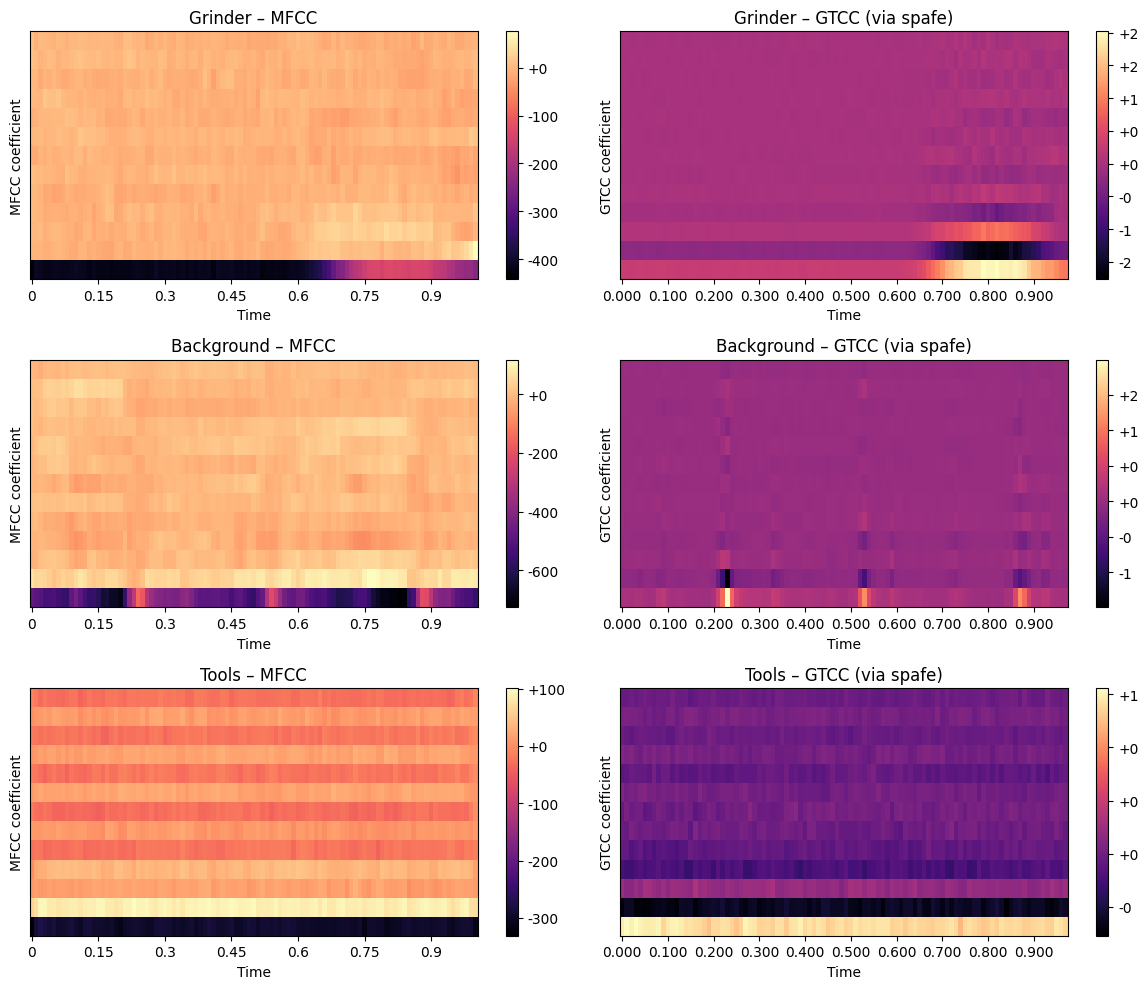

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Find one example file per class from processed audio
PROC_DIR = DATA_DIR / "processed" / "universal" if "DATA_DIR" in globals() else Path("../data/processed/universal")

example_files = {}
for class_name in ["grinder", "background", "tools"]:
    # Get first file of each class
    files = list(PROC_DIR.glob(f"{class_name}_*.wav"))
    if files:
        example_files[class_name] = files[0]

if len(example_files) == 3:
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    
    for idx, (cls, filepath) in enumerate(example_files.items()):
        # Load audio
        y, sr = librosa.load(filepath, sr=16000)
        
        # Compute MFCCs (13 coefficients)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=512, hop_length=160)
        
        # Plot MFCC heatmap
        img1 = librosa.display.specshow(
            mfcc, 
            x_axis="time", 
            sr=sr,
            hop_length=160,
            ax=axes[idx, 0],
            cmap="magma"
        )
        axes[idx, 0].set_title(f"{cls.capitalize()} – MFCC")
        axes[idx, 0].set_ylabel("MFCC coefficient")
        fig.colorbar(img1, ax=axes[idx, 0], format="%+2.0f")
        
        # Compute GTCCs using spafe (called gfcc = Gammatone Frequency Cepstral Coefficients)
        try:
            from spafe.features.gfcc import gfcc
            
            # Compute GFCCs (same as GTCCs)
            gfcc_feats = gfcc(
                sig=y,
                fs=sr,
                num_ceps=13,
                nfilts=40,
                nfft=512,
                low_freq=50,
                high_freq=sr//2,  # 8000 Hz for 16kHz sampling
            )
            
            # Plot GFCC/GTCC heatmap (transpose to match librosa format)
            img2 = librosa.display.specshow(
                gfcc_feats.T,  # Transpose: spafe returns (frames, coeffs)
                x_axis="time",
                sr=sr,
                hop_length=160,
                ax=axes[idx, 1],
                cmap="magma"
            )
            axes[idx, 1].set_title(f"{cls.capitalize()} – GTCC (via spafe)")
            axes[idx, 1].set_ylabel("GTCC coefficient")
            fig.colorbar(img2, ax=axes[idx, 1], format="%+2.0f")
            
        except ImportError:
            axes[idx, 1].text(
                0.5, 0.5, 
                "spafe not installed\n\nInstall with:\npip install spafe",
                ha="center", va="center", fontsize=10
            )
            axes[idx, 1].set_title(f"{cls.capitalize()} – GTCC (unavailable)")
            axes[idx, 1].axis("off")
        except Exception as e:
            axes[idx, 1].text(
                0.5, 0.5, 
                f"Error computing GTCC:\n{str(e)}",
                ha="center", va="center", fontsize=9
            )
            axes[idx, 1].set_title(f"{cls.capitalize()} – GTCC (error)")
            axes[idx, 1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("Could not find example files for all three classes.")
    print(f"Found: {list(example_files.keys())}")



### 4.3 Neural Network Input Features: Mel, Delta, and Delta-Delta

For CNN input, we use 3-channel spectrograms:
- **Channel 1 (Mel):** Log-mel spectrogram showing time-frequency energy distribution
- **Channel 2 (Delta):** First-order differences (velocity) capturing how mel energies change frame-to-frame
- **Channel 3 (Delta-Delta):** Second-order differences (acceleration) capturing the rate of change

These three channels together give the CNN temporal context about how sounds evolve.


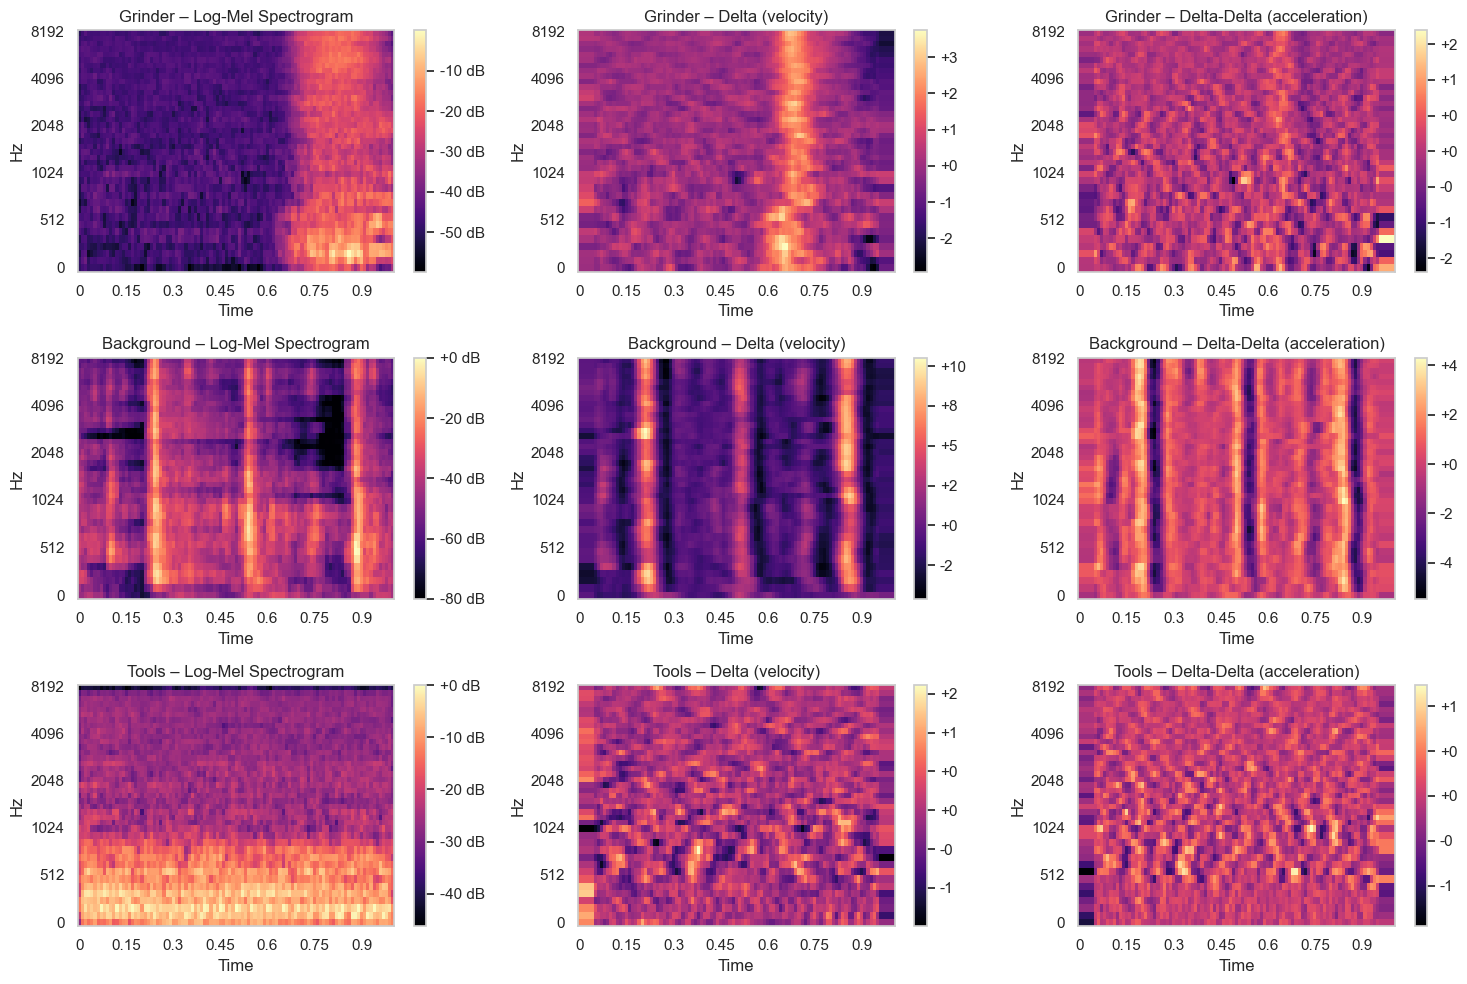

In [25]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

if len(example_files) == 3:
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    
    for row_idx, (cls, filepath) in enumerate(example_files.items()):
        # Load audio
        y, sr = librosa.load(filepath, sr=16000)
        
        # Compute log-mel spectrogram (40 mel bins, as per your project spec)
        mel_spec = librosa.feature.melspectrogram(
            y=y, 
            sr=sr, 
            n_fft=512, 
            hop_length=160, 
            n_mels=40
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Compute delta (first derivative)
        delta = librosa.feature.delta(log_mel, order=1)
        
        # Compute delta-delta (second derivative / acceleration)
        delta_delta = librosa.feature.delta(log_mel, order=2)
        
        # Plot log-mel spectrogram
        img1 = librosa.display.specshow(
            log_mel,
            x_axis="time",
            y_axis="mel",
            sr=sr,
            hop_length=160,
            ax=axes[row_idx, 0],
            cmap="magma"
        )
        axes[row_idx, 0].set_title(f"{cls.capitalize()} – Log-Mel Spectrogram")
        fig.colorbar(img1, ax=axes[row_idx, 0], format="%+2.0f dB")
        
        # Plot delta
        img2 = librosa.display.specshow(
            delta,
            x_axis="time",
            y_axis="mel",
            sr=sr,
            hop_length=160,
            ax=axes[row_idx, 1],
            cmap="magma"
        )
        axes[row_idx, 1].set_title(f"{cls.capitalize()} – Delta (velocity)")
        fig.colorbar(img2, ax=axes[row_idx, 1], format="%+2.0f")
        
        # Plot delta-delta
        img3 = librosa.display.specshow(
            delta_delta,
            x_axis="time",
            y_axis="mel",
            sr=sr,
            hop_length=160,
            ax=axes[row_idx, 2],
            cmap="magma"
        )
        axes[row_idx, 2].set_title(f"{cls.capitalize()} – Delta-Delta (acceleration)")
        fig.colorbar(img3, ax=axes[row_idx, 2], format="%+2.0f")
    
    plt.tight_layout()
    plt.show()
else:
    print("Could not find example files for all three classes.")


### 4.4 Combined 3-Channel CNN Input (RGB-style visualization)

This shows what the CNN actually "sees" – all three channels stacked together,
normalized and displayed as an RGB-like image.


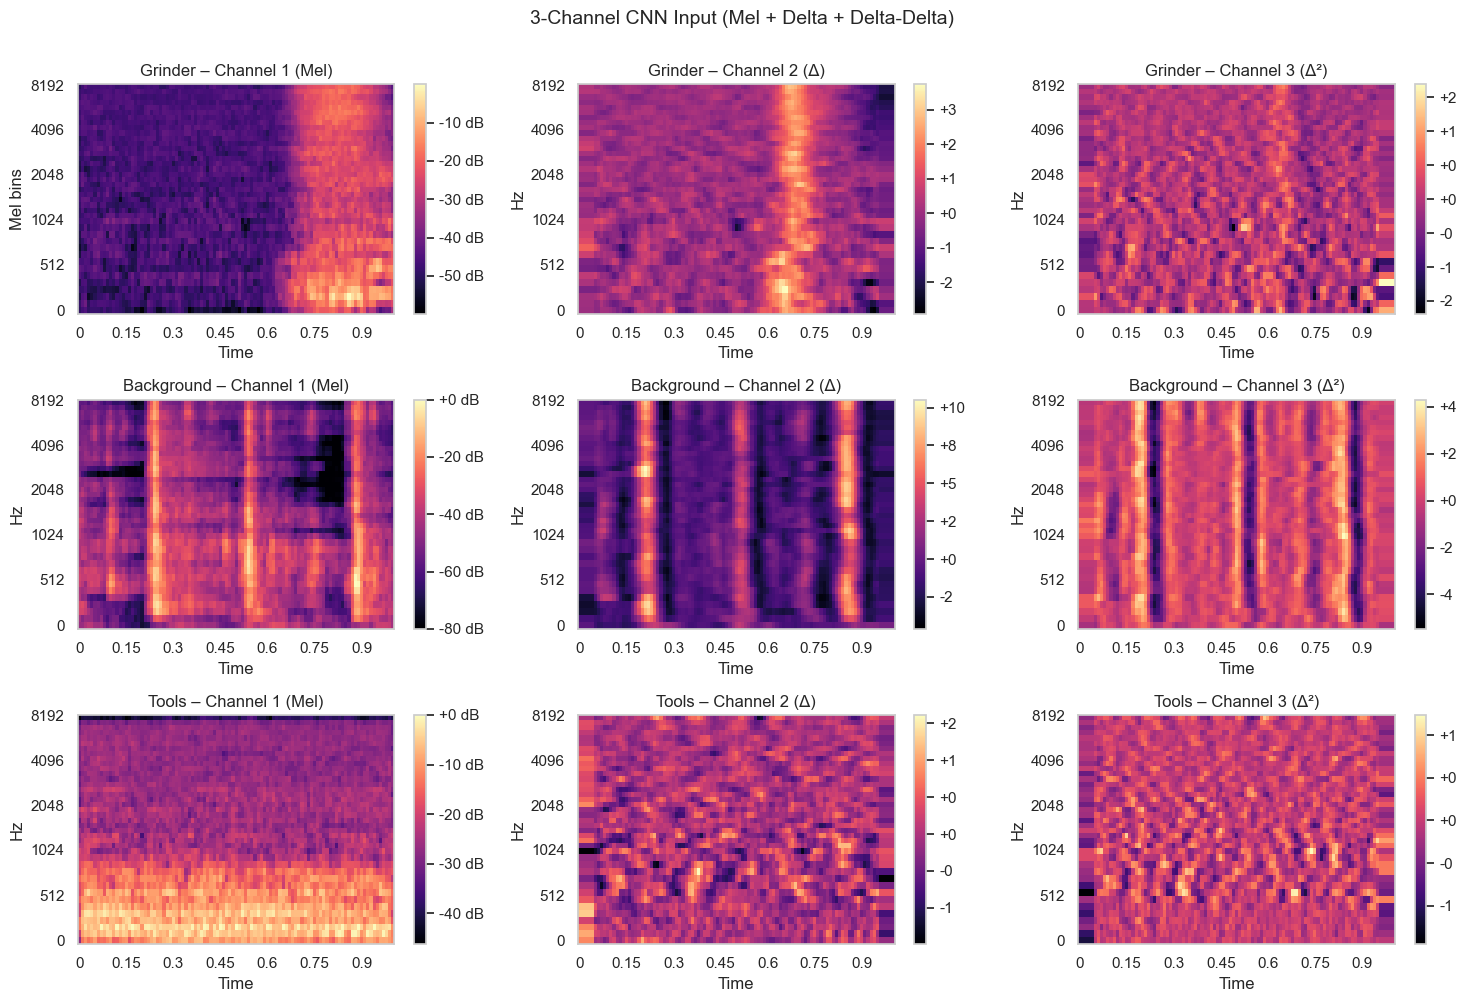

In [26]:
if len(example_files) == 3:
    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    
    for row_idx, (cls, filepath) in enumerate(example_files.items()):
        # Load and compute features
        y, sr = librosa.load(filepath, sr=16000)
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=512, hop_length=160, n_mels=40
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        delta = librosa.feature.delta(log_mel, order=1)
        delta_delta = librosa.feature.delta(log_mel, order=2)
        
        # Plot each channel separately with magma colormap
        # Channel 1: Log-Mel
        img1 = librosa.display.specshow(
            log_mel,
            x_axis="time",
            y_axis="mel",
            sr=sr,
            hop_length=160,
            ax=axes[row_idx, 0],
            cmap="magma"
        )
        axes[row_idx, 0].set_title(f"{cls.capitalize()} – Channel 1 (Mel)")
        if row_idx == 0:
            axes[row_idx, 0].set_ylabel("Mel bins")
        fig.colorbar(img1, ax=axes[row_idx, 0], format="%+2.0f dB")
        
        # Channel 2: Delta
        img2 = librosa.display.specshow(
            delta,
            x_axis="time",
            y_axis="mel",
            sr=sr,
            hop_length=160,
            ax=axes[row_idx, 1],
            cmap="magma"
        )
        axes[row_idx, 1].set_title(f"{cls.capitalize()} – Channel 2 (Δ)")
        fig.colorbar(img2, ax=axes[row_idx, 1], format="%+2.0f")
        
        # Channel 3: Delta-Delta
        img3 = librosa.display.specshow(
            delta_delta,
            x_axis="time",
            y_axis="mel",
            sr=sr,
            hop_length=160,
            ax=axes[row_idx, 2],
            cmap="magma"
        )
        axes[row_idx, 2].set_title(f"{cls.capitalize()} – Channel 3 (Δ²)")
        fig.colorbar(img3, ax=axes[row_idx, 2], format="%+2.0f")
    
    plt.suptitle("3-Channel CNN Input (Mel + Delta + Delta-Delta)", 
                 fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()



In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

# Reuse existing project paths if they exist, else default
PROJECT_ROOT = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path("..").resolve()
DATA_DIR = DATA_DIR if "DATA_DIR" in globals() else PROJECT_ROOT / "data"
FEATURES_DIR = FEATURES_DIR if "FEATURES_DIR" in globals() else DATA_DIR / "features"
PROC_DIR = PROC_DIR if "PROC_DIR" in globals() else DATA_DIR / "processed" / "universal"

# Classical feature files (as per 03_classical_feature_extraction)
combined_feats_path = FEATURES_DIR / "classical" / "combined_unbalanced_features.npy"
labels_path = FEATURES_DIR / "classical" / "labels.npy"

if combined_feats_path.exists() and labels_path.exists():
    X_classical = np.load(combined_feats_path)
    y = np.load(labels_path)
    print("Loaded classical features:", X_classical.shape)
else:
    X_classical, y = None, None
    print("Classical feature files not found; run 03_feature_extraction first.")


Loaded classical features: (60348, 260)


In [15]:
if y is not None:
    # Adjust mapping to your project labels
    label_map = {0: "background", 1: "grinder", 2: "tools"}
    label_names = np.vectorize(label_map.get)(y)
else:
    label_names = None


/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_11712/1543971771.py:20: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


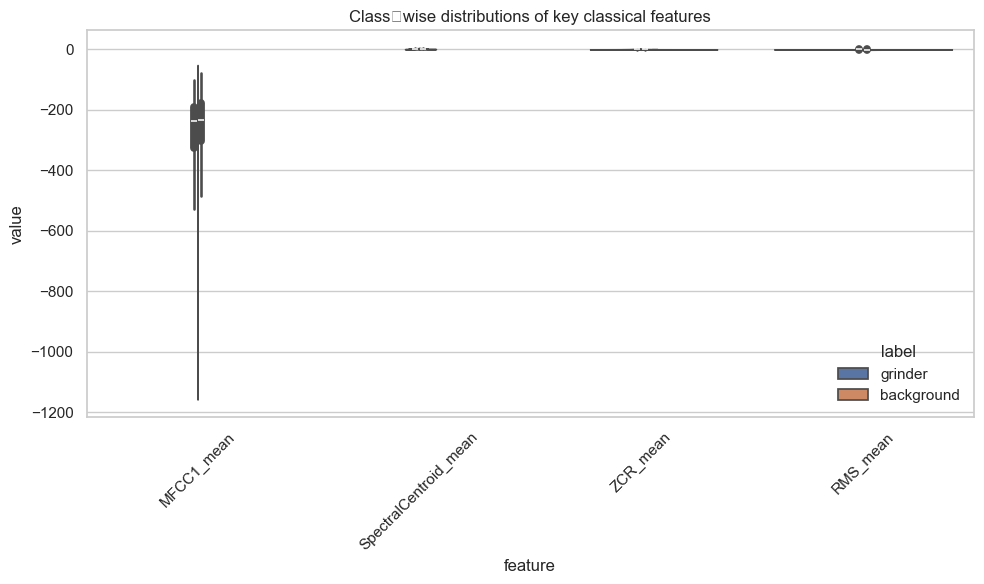

In [16]:
if X_classical is not None and label_names is not None:
    # Adjust indices to your actual feature ordering
    FEATURE_IDX = {
        "MFCC1_mean": 0,
        "SpectralCentroid_mean": 52,
        "ZCR_mean": 60,
        "RMS_mean": 70,
    }

    df_feats = pd.DataFrame({
        "label": label_names,
        **{name: X_classical[:, idx] for name, idx in FEATURE_IDX.items()},
    })

    plt.figure(figsize=(10, 6))
    df_melt = df_feats.melt(id_vars="label", var_name="feature", value_name="value")
    sns.violinplot(data=df_melt, x="feature", y="value", hue="label", split=True)
    plt.title("Class‑wise distributions of key classical features")
    plt.xticks(rotation=45)
    plt.tight_layout()
else:
    print("Skip 5.1: classical features or labels not loaded.")


/var/folders/41/zp1kfbg927lf6brpdz24gbd00000gn/T/ipykernel_11712/498565249.py:28: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/harryirving/Development/projects/ai-ml/BikeAIv5/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


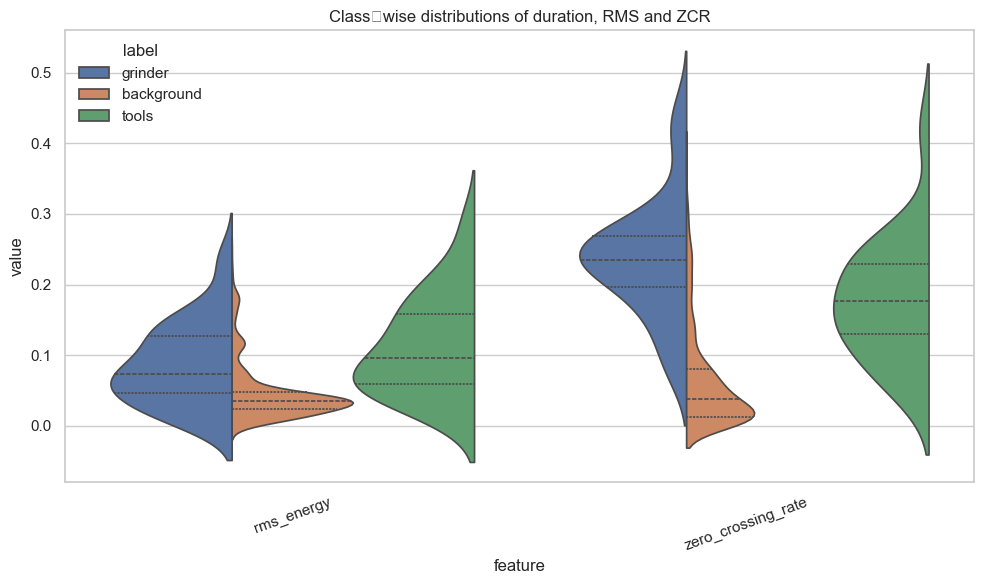

In [17]:
# 5.1 Class-wise distributions of simple audio features (from df_success)

if "df_success" in globals():
    plot_df = df_success.copy()
    plot_df.rename(columns={"class": "label"}, inplace=True)

    # Focus on features you already computed in analyze_audio_file
    features_to_plot = ["rms_energy", "zero_crossing_rate"]

    melted = plot_df.melt(
        id_vars="label",
        value_vars=features_to_plot,
        var_name="feature",
        value_name="value",
    )

    plt.figure(figsize=(10, 6))
    sns.violinplot(
        data=melted,
        x="feature",
        y="value",
        hue="label",
        split=True,
        inner="quart"
    )
    plt.title("Class‑wise distributions of duration, RMS and ZCR")
    plt.xticks(rotation=20)
    plt.tight_layout()
else:
    print("df_success not found – run the analysis cell above first.")


In [18]:
from sklearn.impute import SimpleImputer

print('Checking for NaN values...')
nan_count = np.isnan(X_classical).sum()

if nan_count > 0:
    print(f'⚠️  Found {nan_count:,} NaN values ({nan_count/(X_classical.shape[0]*X_classical.shape[1])*100:.3f}% of data)')
    print('   Applying median imputation...')
    
    imputer = SimpleImputer(strategy='median')
    X_classical = imputer.fit_transform(X_classical)
    
    # Verify
    remaining_nans = np.isnan(X_classical).sum()
    if remaining_nans == 0:
        print('   ✓ All NaN values handled')
    else:
        print(f'   ⚠️  Still have {remaining_nans} NaN values')
else:
    print('✓ No NaN values detected')

Checking for NaN values...
⚠️  Found 20 NaN values (0.000% of data)
   Applying median imputation...
   ✓ All NaN values handled


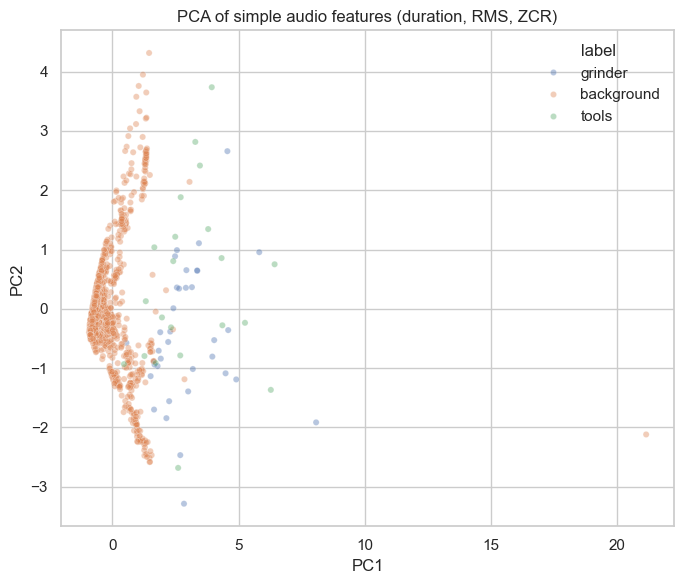

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if "df_success" in globals():
    # Build a simple feature matrix from the analysis dataframe
    feat_cols = ["duration", "rms_energy", "zero_crossing_rate"]
    X = df_success[feat_cols].values
    labels = df_success["class"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "label": labels,
    })

    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="label",
        alpha=0.4,
        s=20
    )
    plt.title("PCA of simple audio features (duration, RMS, ZCR)")
    plt.tight_layout()
else:
    print("df_success not found – run the analysis step first.")


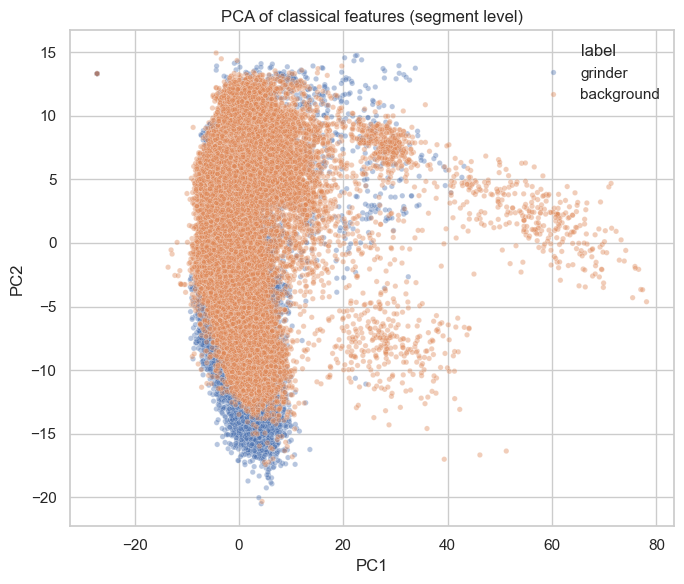

In [20]:
if X_classical is not None and label_names is not None:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_classical)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "label": label_names,
    })

    plt.figure(figsize=(7, 6))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="label", alpha=0.4, s=15)
    plt.title("PCA of classical features (segment level)")
    plt.tight_layout()
else:
    print("Skip 5.2: classical features or labels not loaded.")


## 6. Class balance and duration (pre-augmentation)

Here we estimate class balance directly from the raw folders and
per-file durations, without relying on any manifest files.


,class,n_files,total_duration_sec
0,grinder,36,1513.043220
1,background,1348,4708.968000
2,tools,21,1077.683141


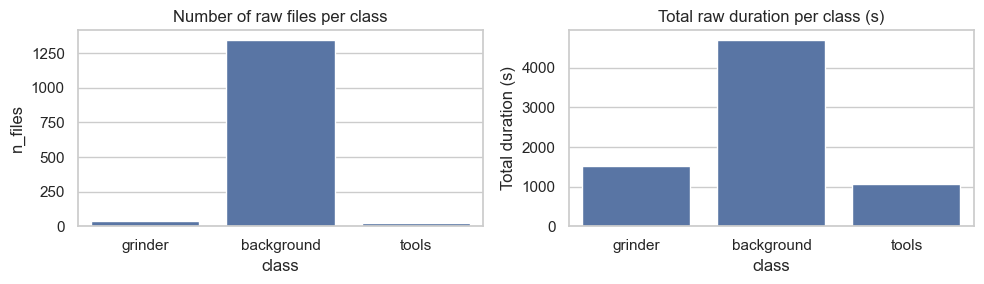

In [21]:

# 6.0 Class counts and total duration from raw folders

if "audio_files_by_class" in globals() and "df_success" in globals():
    # 1) Number of files per class from the directory scan
    file_counts = {
        cls: len(files) for cls, files in audio_files_by_class.items()
    }

    # 2) Total duration per class from the analysis dataframe
    duration_per_class = (
        df_success[df_success["status"] == "success"]
        .groupby("class")["duration"]
        .sum()
    )

    balance_df = pd.DataFrame({
        "class": list(file_counts.keys()),
        "n_files": [file_counts[c] for c in file_counts.keys()],
        "total_duration_sec": [duration_per_class.get(c, 0.0) for c in file_counts.keys()],
    })

    display(balance_df)

    # Bar plots for use in slides
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    sns.barplot(
        data=balance_df,
        x="class",
        y="n_files",
        ax=axes[0]
    )
    axes[0].set_title("Number of raw files per class")

    sns.barplot(
        data=balance_df,
        x="class",
        y="total_duration_sec",
        ax=axes[1]
    )
    axes[1].set_title("Total raw duration per class (s)")
    axes[1].set_ylabel("Total duration (s)")
    plt.tight_layout()
else:
    print("Need both audio_files_by_class and df_success – run the earlier cells first.")


In [22]:
if manifest_path.exists():
    # Ensure we have proc_df from the previous cell
    if "proc_df" not in globals():
        proc_df = pd.read_csv(manifest_path)

    # Parse the augmentation dict safely
    def parse_aug(s):
        try:
            return ast.literal_eval(s)
        except Exception:
            return {}

    aug_dicts = proc_df["augmentation"].apply(parse_aug)
    proc_df["is_original"] = aug_dicts.apply(lambda d: d.get("original", False))

    orig_stats = (
        proc_df
        .groupby(["class", "is_original"])
        .size()
        .reset_index(name="n_segments")
    )
    orig_stats["approx_total_duration_sec"] = \
        orig_stats["n_segments"] * SEGMENT_LENGTH_SEC

    display(orig_stats)

    plt.figure(figsize=(6, 4))
    sns.barplot(
        data=orig_stats,
        x="class",
        y="n_segments",
        hue="is_original"
    )
    plt.title("Original vs augmented segments per class (post‑augmentation)")
    plt.ylabel("Number of 1 s segments")
    plt.tight_layout()


NameError: name 'manifest_path' is not defined

Loaded processed manifest: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/data/processed/manifest.csv shape: (60348, 8)


,class,n_segments,approx_total_duration_sec
0,grinder,32938,32938.0
1,tools,19341,19341.0
2,background,8069,8069.0


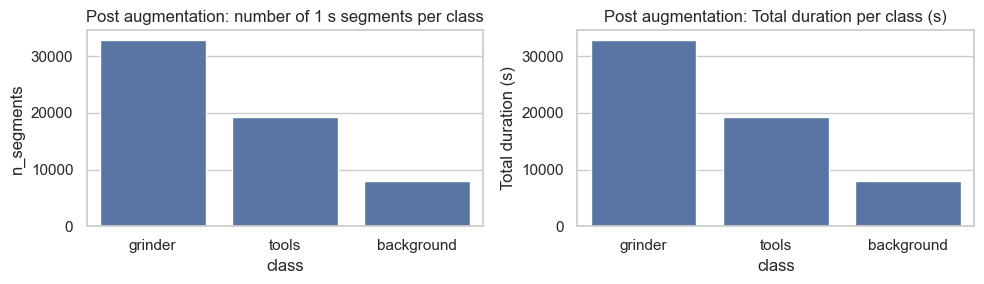

In [ ]:

import ast

sns.set(style="whitegrid")

PROC_ROOT = DATA_DIR / "processed" if "DATA_DIR" in globals() else Path("../data/processed")
manifest_path = PROC_ROOT / "manifest.csv"

if manifest_path.exists():
    proc_df = pd.read_csv(manifest_path)
    print("Loaded processed manifest:", manifest_path, "shape:", proc_df.shape)

    # Basic class balance: one row per 1 s segment
    class_counts = (
        proc_df["class"]
        .value_counts()
        .reset_index(name="n_segments")
        .rename(columns={"index": "class"})
    )

    # Each segment is 1 second long (from your preprocessing spec),
    # so total duration is just count × 1 s.
    SEGMENT_LENGTH_SEC = 1.0
    class_counts["approx_total_duration_sec"] = (
        class_counts["n_segments"] * SEGMENT_LENGTH_SEC
    )

    display(class_counts)

    fig, axes = plt.subplots(1,2, figsize=(10, 3))
    
    sns.barplot(data=class_counts, x="class", y="n_segments", ax=axes[0])
    axes[0].set_title("Post augmentation: number of 1 s segments per class")

    sns.barplot(
        data=class_counts,
        x="class",
        y="approx_total_duration_sec",
        ax=axes[1],
    )
    axes[1].set_title("Post augmentation: Total duration per class (s)")
    axes[1].set_ylabel("Total duration (s)")

    plt.tight_layout()
else:
    print("Processed manifest not found at:", manifest_path)



### 5.2 PCA view of feature space – what are PC1 and PC2?

Principal Component Analysis (PCA) computes new axes (principal components)
that are linear combinations of the original features.  

- **PC1** (principal component 1) is the single direction in feature space
  that explains the most variance across all segments.
- **PC2** is the next best direction, orthogonal to PC1, that explains the
  second most variance.

Plotting segments on (PC1, PC2) gives a 2D map where points that are close
together have similar feature vectors, and points far apart are quite
different. If grinder and background segments cluster in different regions
on this plot, it shows that the chosen features carry useful information
for separating the classes. [web:32]


## 9. Save Summary Report

In [ ]:
if len(df_success) > 0: 
    df_success.to_csv(RESULTS_DIR / '01_dataset_summary.csv', index=False) 
    print(f'✓ Saved: {RESULTS_DIR / "01_dataset_summary.csv"}') 
     
    summary_stats = { 
        'timestamp': datetime.now().isoformat(), 
        'total_files': len(df_success), 
        'class_distribution': df_success['class'].value_counts().to_dict(), 
        'total_duration_seconds': float(df_success['duration'].sum()), 
        'clipped_files': int(df_success['is_clipped'].sum()), 
        'mean_silence_ratio': float(df_success['silence_ratio'].mean()) 
    } 
     
    with open(RESULTS_DIR / '01_dataset_summary.json', 'w') as f: 
        json.dump(summary_stats, f, indent=2) 
    print(f'✓ Saved: {RESULTS_DIR / "01_dataset_summary.json"}')

✓ Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/01_dataset_summary.csv
✓ Saved: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results/01_dataset_summary.json


## 10. Log to MLflow

In [ ]:
if len(df_success) > 0: 
    with mlflow.start_run(run_name='01_data_exploration'): 
        mlflow.log_metric('total_files', len(df_success)) 
        mlflow.log_metric('total_duration_hours', df_success['duration'].sum()/3600) 
        mlflow.log_metric('clipped_files', df_success['is_clipped'].sum()) 
        for cls, count in df_success['class'].value_counts().items(): 
            mlflow.log_metric(f'num_{cls}_files', count) 
        mlflow.set_tags({'stage': 'data_exploration', 'notebook': '01'}) 
        for f in [RESULTS_DIR/'01_dataset_summary.csv', FIGURES_DIR/'01_dataset_statistics.png']: 
            if f.exists(): 
                mlflow.log_artifact(str(f)) 
        print('✓ Logged to MLflow')

✓ Logged to MLflow


## 11. Summary and Next Steps

In [ ]:
print('='*70) 
print('DATA EXPLORATION COMPLETE') 
print('='*70) 
if len(df_success) > 0: 
    print(f' ✓ Analyzed {len(df_success)} audio files') 
    print(f'✓ Total duration: {df_success["duration"].sum()/60:.1f} minutes') 
    print(f'✓ Classes: {list(df_success["class"].unique())}') 
    print(f' Saved to: {RESULTS_DIR}') 
    print(' Next notebook: 02_universal_preprocessing.ipynb') 
else: 
    print(' ⚠️  No audio files found!') 
    print('Add files to data/raw/ and rerun this notebook') 
print(' ✓ Notebook 01 Complete!')

DATA EXPLORATION COMPLETE
 ✓ Analyzed 1405 audio files
✓ Total duration: 121.7 minutes
✓ Classes: ['grinder', 'background', 'tools']
 Saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv5/results
 Next notebook: 02_universal_preprocessing.ipynb
 ✓ Notebook 01 Complete!
